# <center> Redes neuronales para el Procesamiento del Lenguaje Natural </center>  
# <center> Práctica 1: Introducción </center>



# Práctica 1: Sentiment Analysis
## Jesús Ferrándiz Alarcón

En esta práctica vamos a implementar modelos de aprendizaje automático para la tarea de análisis de sentimiento en reseñas de películas.

Los datos de entrada son reseñas de películas en strings y las etiquetas son 0 (negativo) o 1 (positivo).

Vamos a comenzar por visualizar los datos de entrada y las etiquetas, hacer un preprocesado de estos datos para poder usarlos en los modelos y finalmente, entrenar y evaluar modelos de aprendizaje automático clásicos y de redes neuronales.

# Imports

In [1]:
# Librerias necesarias
# Matplotlib conf
import matplotlib.pyplot as plt
%matplotlib inline
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':40,
         'ytick.labelsize': 40
}
plt.rcParams.update(params)
# Seaborn conf
import seaborn as sns
sns.set(style='darkgrid')
sns.set_palette(sns.color_palette("Blues"))

import sys

#Procesado de datos
import pandas as pd
import numpy as np
import operator

#Modelos
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Dataset
Vamos a cargar el dataset usando rutas relativas.

In [2]:
training_set = pd.read_csv('./Dataset_reviews/train_reviews.csv')
print(f"Training set shape: {training_set.shape}, columns: {training_set.columns.tolist()}")
test_set = pd.read_csv('./Dataset_reviews/test_reviews.csv')
print(f"Test set shape: {test_set.shape}, columns: {test_set.columns.tolist()}")

Training set shape: (8000, 3), columns: ['id', 'review', 'sentiment']
Test set shape: (2000, 3), columns: ['id', 'review', 'sentiment']


Como se muestra en el enunciado de la práctica, esperamos que el dataset de entrenamiento tenga 8000 muestras y el de test 2000. Estos tienen las columnas:
- `id`: identificador único de la review
- `review`: texto de la review
- `sentiment`: etiqueta de la review

In [3]:
# Inspeccionamos el aspecto del conjunto de entrenamiento
training_set.head(20)

,id,review,sentiment
0,17527,People tried to make me believe that the premi...,negative
1,24155,I have been wanting to see cut since the day i...,positive
2,21972,This movie is terrible. The suspense is spent ...,negative
3,4565,I hope she can keep acting and directing. She'...,positive
4,22098,I fell in love with this silent action drama. ...,positive
5,5138,Shame Shame Shame on UA/DW for what you do! <b...,negative
6,16932,It's not very often a movie can literally make...,positive
7,13181,I was very interested to see this movie when i...,positive
8,3299,It might not be the best movie of 2006 but it ...,positive
9,18982,I went to see the Omega Code with a group of o...,negative


In [5]:
# Inspeccionamos el aspecto del conjunto de test
test_set.head(20)

,id,review,sentiment
0,6666,Movies about dinosaurs can be entertaining. So...,negative
1,23267,If it's action and adventure you want in a mov...,positive
2,2897,Barbra Streisand is a tour de force in this Ho...,positive
3,23177,I borrowed this movie despite its extremely lo...,positive
4,14171,"""Baby Face"" is a precode melodrama starring a ...",positive
5,17212,Pokemon 3 is little more than three or four ep...,negative
6,22006,"Well, I'd be lying if I said that this could e...",negative
7,11408,"""GI Samurai"" sees Sonny Chiba and some other g...",positive
8,10017,Very low-budget police procedural film about h...,negative
9,4824,I was excited to hear that Cesar Montano had d...,negative


Vamos a ver qué etiquetas únicas tenemos en el conjunto de entrenamiento y de test.
Para revisar que el dataset está bien formateado.

In [4]:
unique_labels_train = training_set['sentiment'].unique()
print(f'Unique labels in training set: {unique_labels_train}')
unique_labels_test = test_set['sentiment'].unique()
print(f'Unique labels in test set: {unique_labels_test}')

assert set(unique_labels_train) == set(unique_labels_test), "Train and test sets have different labels"

Unique labels in training set: ['negative' 'positive']
Unique labels in test set: ['negative' 'positive']


Verificamos que todas las etiquetas son 'positive' o 'negative'.

In [5]:
accepted_labels = {'positive', 'negative'}
rows_with_problems = training_set[training_set.sentiment.isin(accepted_labels) == False]
rows_with_problems

,id,review,sentiment


En este dataset no se da el problema que tenía el dataset de fake news donde había 
problema con el formato de los datos desplazando cierta información de columna.

Finalmente, juntamos ambos dataset para facilitar el pre-procesado.

In [6]:
dataset = pd.concat([training_set, test_set])
dataset.shape
dataset.columns

Index(['id', 'review', 'sentiment'], dtype='object')

# Inspección de los datos

Vamos a revisar primero la distribución de las etiquetas en el conjunto de entrenamiento.

([0, 1], [Text(0, 0, 'positive'), Text(1, 0, 'negative')])

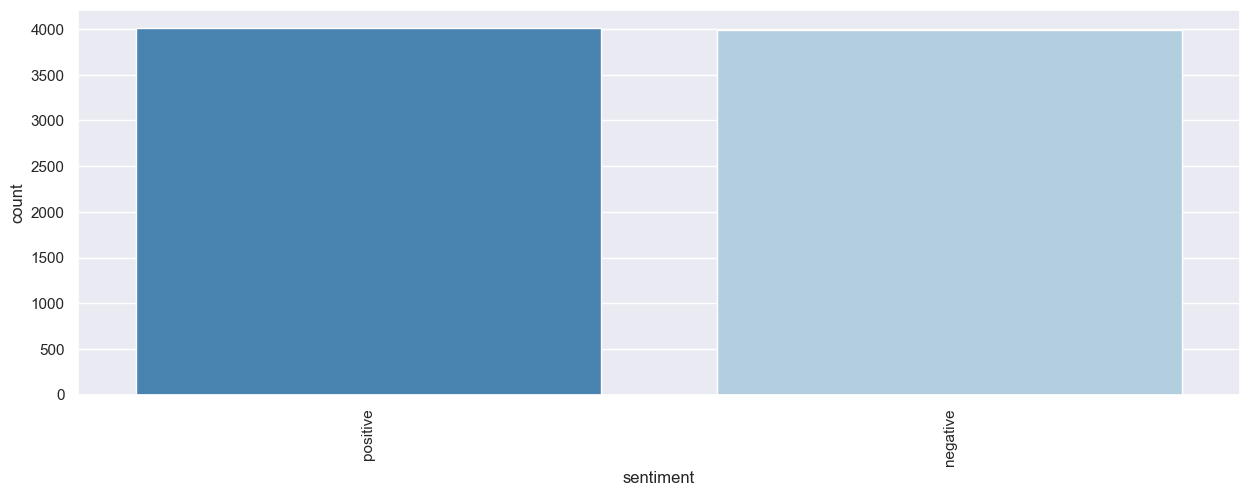

In [7]:
from collections import Counter
sns.countplot(data=training_set, x=training_set.sentiment, order=[x for x, count in sorted(Counter(training_set.sentiment).items(), key=lambda x: -x[1])], palette="Blues_r")
plt.xticks(rotation=90)

Podemos ver que no existe un desbalanceo. No tenemos que preocuparnos por este problema.

**Inpeccionamos ahora el texto de cada una de las reviews.**

In [8]:
from matplotlib import interactive

# Agrupamos las reviews por su etiqueta
df = pd.DataFrame({"text": training_set.review, "label": training_set.sentiment})
grouped = df.groupby(['label']).apply(lambda x: x['text'].sum())
grouped_df = pd.DataFrame({'label': grouped.index, 'text': grouped.values})

Muestro las palabras más frecuentes en las reviews positivas y negativas.
En este momento, palabras son aquellos tokens separados por espacios en blanco.

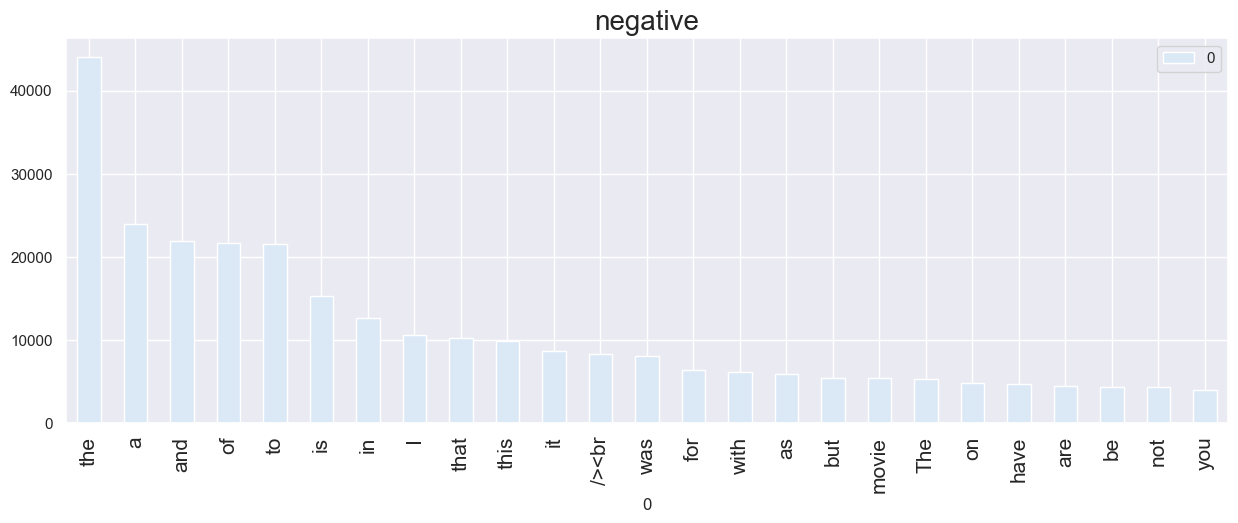

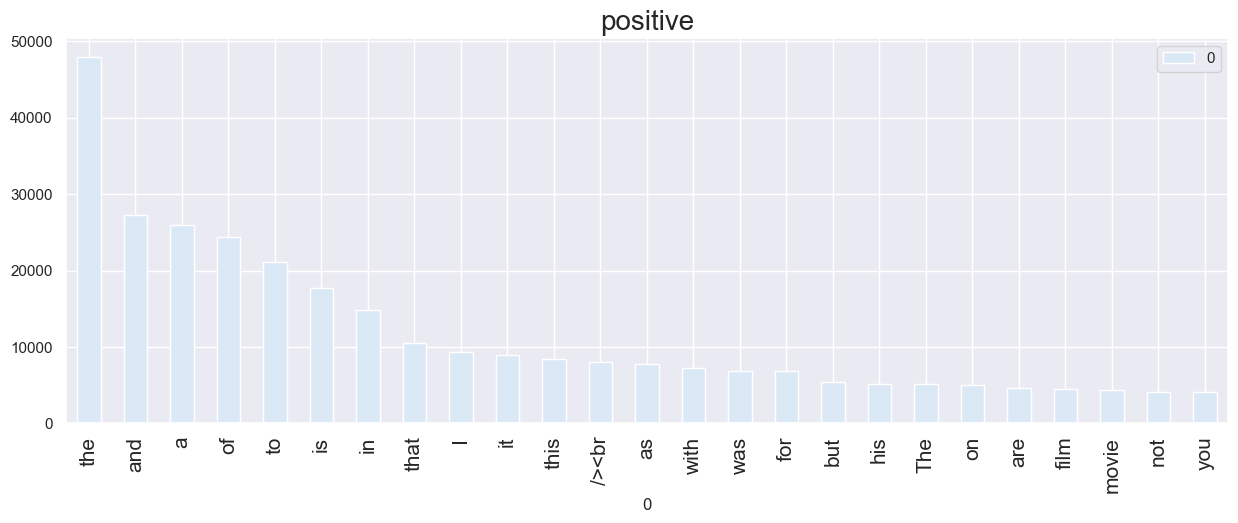

In [9]:
from nltk.tokenize import WhitespaceTokenizer
tokenizer = WhitespaceTokenizer()

for ii, text in enumerate(grouped_df.text):
    pd.DataFrame(tokenizer.tokenize(text)).apply(pd.value_counts).head(25).plot(kind="bar")
    plt.title(grouped_df.label[ii], fontsize=20)
    plt.xticks(fontsize=15)
    interactive(True)
    plt.show()

Observamos que las palabras más frequentes para ambas clases son **stopwords**. Estas son difíciles que nos ayuden a discriminar entre clases. Eliminaremos estas palabras.

Se observa también que la misma palabra aparece como dos por el uso de mayúsculas: 'the' y 'The'. **Normalizaremos** las palabras.

También encontramos la misma palabra en distintas formas: 'is', 'are'. Evitaremos este problema aplicando **stemming** o **lematización**.

Por último, vemos que hay una palabra 'rara' entre las más frecuentes: '/><br'. Parece un artefacto de texto HTML. Vamos a ver primero, cómo son las reviews que contienen esta palabra.

In [10]:
reviews_with_artifact = training_set[training_set.review.str.contains('/><br')]
reviews_with_artifact.shape
reviews_with_artifact.head().review.values

array(["I have been wanting to see cut since the day i have heard of it, which was sometime last year. Anyway i got to see today, and when the movie started i thought that it started rather week but it got better after 10 mins or so. I thought that the movie was pretty good. but the thing i didn't like was how the killer was created, i was thinking just before i rented that it would probably suck just like Urban legends: final cut, i almost died it. mostly everything in UL final cut needed to be improved. CUT is 100 times better than UL:final cut. The best part of CUT is the killer and the death scenes. The killer kicks MO F***ING ASS.<br /><br />i give cut a 8 out of 10",
       'This movie is terrible. The suspense is spent waiting for a point. There isn\'t much of one.<br /><br />Aside from a few great lines ( "I found a tooth in my apartment" ), and the main characters dedication to killing himself, it\'s a collection of supposedly eerie sounds.<br /><br />',
       'I fell in love

En el texto vemos que la palabra rara `'/><br'` aparece siempre junto con: `<br /><br />`. Parece indicar saltos de línea. Vamos a eliminar en la etapa de pre-procesado estos artefactos.

In [11]:
reviews_with_artifact = training_set[training_set.review.str.contains('<br /><br />')]
reviews_with_artifact.shape
reviews_with_artifact.head(5).review.values

array(["I have been wanting to see cut since the day i have heard of it, which was sometime last year. Anyway i got to see today, and when the movie started i thought that it started rather week but it got better after 10 mins or so. I thought that the movie was pretty good. but the thing i didn't like was how the killer was created, i was thinking just before i rented that it would probably suck just like Urban legends: final cut, i almost died it. mostly everything in UL final cut needed to be improved. CUT is 100 times better than UL:final cut. The best part of CUT is the killer and the death scenes. The killer kicks MO F***ING ASS.<br /><br />i give cut a 8 out of 10",
       'This movie is terrible. The suspense is spent waiting for a point. There isn\'t much of one.<br /><br />Aside from a few great lines ( "I found a tooth in my apartment" ), and the main characters dedication to killing himself, it\'s a collection of supposedly eerie sounds.<br /><br />',
       'I fell in love

In [12]:
from bs4 import BeautifulSoup
import re

def strip_html_remove_links(text):
    soup = BeautifulSoup(text, "html.parser")
    for a in soup.find_all("a"):
        a.decompose()

    text = soup.get_text(separator=" ")

    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [13]:
sample = reviews_with_artifact.head().review.values
clean_sample = strip_html_remove_links(sample[2])
print(f"Original review:\n{sample[2]}\n\nHTML Cleaned review:\n{clean_sample}")

Original review:
I fell in love with this silent action drama. Kurt Russell and only Kurt Russell could have played this so well. Raised from childhood to know nothing but war and fighting, Todd (Kurt Russell) is dumped on a planet after being made obsolete by genetically engineered soldiers.<br /><br />The stage is set and another classic icon of action movies was born - SOLDIER. Not Rambo, not Schwarzenegger, not Bruce Willis, not Mel Gibson, not Jason Statham - Kurt Russell owns this role and made it entirely his - original, daring, and all too human. I miss the fact that sequels were never made.<br /><br />10/10<br /><br />-LD<br /><br />_________<br /><br />my faith: http://www.angelfire.com/ny5/jbc33/

HTML Cleaned review:
I fell in love with this silent action drama. Kurt Russell and only Kurt Russell could have played this so well. Raised from childhood to know nothing but war and fighting, Todd (Kurt Russell) is dumped on a planet after being made obsolete by genetically engin

# Pre-procesado y preparación de datos

Comenzaremos con un pre-procesado básico del pipeline de NLP:
- Eliminación de artefactos HTML.
- Extracción de palabras.
- Lematización para extraer el lema como representación de las posibles formas y variantes de una misma palabra.
- Stemming para reducir las palabras a su raíz.
- Eliminación de stopwords.

In [14]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk import PorterStemmer

import re

nltk.download('stopwords')
nltk.download('wordnet')

def process_text(raw_text, keep_numbers=True):
    #Eliminamos HTML y links
    no_html_links_text = strip_html_remove_links(raw_text)

    pattern = "[^a-zA-Z0-9]" if keep_numbers else "[^a-zA-Z]"
    #Consideramos únicamente letras utilizando una expresión regular
    letters_numbers_only = re.sub(pattern, " ", no_html_links_text)

    #Convertimos todo a minúsculas
    words = letters_numbers_only.lower().split()
    
    #Eliminamos las stopwords
    stop_words = set(stopwords.words("english"))
    not_stop_words = [w for w in words if not w in stop_words]
    
    #Lematización
    wordnet_lemmatizer = WordNetLemmatizer()
    lemmatized = [wordnet_lemmatizer.lemmatize(word) for word in not_stop_words]
    
    #Stemming
    stemmer = PorterStemmer()
    stemmed = [stemmer.stem(word) for word in lemmatized]
    
    return( " ".join( stemmed ))  

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jeferal/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/jeferal/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [15]:
sample_input = "I give the movie a 10/10"
print(f"Original review:\n{sample_input}\n\nProcessed review:\n{process_text(sample_input)}")

Original review:
I give the movie a 10/10

Processed review:
give movi 10 10


La siguiente frase la uso para testear y comprobar el pre-procesado en una frase
que tiene una negación. Se puede ver que el resultado tiene un significado opuesto.

In [16]:
sample_input = "I didn't like the movie"
print(f"Original review:\n{sample_input}\n\nProcessed review:\n{process_text(sample_input)}")

Original review:
I didn't like the movie

Processed review:
like movi


Otra versión para testear de pre-procesado. Se trata de mantener las palabras de negación.

In [17]:
import re
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

negation_words = {"not", "no", "never", "nor"}

def process_text_v2(raw_text, keep_numbers=True):

    text = contractions.fix(raw_text)

    text = strip_html_remove_links(text)

    text = text.lower()

    pattern = r"[^a-z0-9 ]" if keep_numbers else r"[^a-z ]"
    text = re.sub(pattern, " ", text)

    words = text.split()

    stop_words = set(stopwords.words("english")) - negation_words
    words = [w for w in words if w not in stop_words]

    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

In [18]:
sample_input = "I didn't like the movie"
print(f"Original review:\n{sample_input}\n\nProcessed review:\n{process_text_v2(sample_input)}")

Original review:
I didn't like the movie

Processed review:
not like movie


Ahora aplicamos la función de pre-procesado a las reviews del dataset.

In [19]:
from tqdm import tqdm
tqdm.pandas()

dataset['clean_review'] = dataset['review'].progress_apply(lambda x: process_text(x))

100%|██████████| 10000/10000 [00:41<00:00, 241.72it/s]


Genero también una columna con las reviews limpias pero eliminando los números.
La intuición es que quizá ciertos números puedan aportar información sobre el sentimiento. Pero
mantengo otra columna sin estos para comparar por si esto no fuese cierto.

In [20]:
dataset['clean_review_only_letters'] = dataset['review'].progress_apply(lambda x: process_text(x, keep_numbers=False))

100%|██████████| 10000/10000 [00:39<00:00, 250.20it/s]


Una última columna con la versión que mantiene negaciones.

In [21]:
dataset['clean_review_v2'] = dataset['review'].progress_apply(lambda x: process_text_v2(x, keep_numbers=False))

100%|██████████| 10000/10000 [00:13<00:00, 761.35it/s]


In [22]:
dataset.head()

,id,review,sentiment,clean_review,clean_review_only_letters,clean_review_v2
0,17527,People tried to make me believe that the premi...,negative,peopl tri make believ premis rubbishi supernat...,peopl tri make believ premis rubbishi supernat...,people tried make believe premise rubbishy sup...
1,24155,I have been wanting to see cut since the day i...,positive,want see cut sinc day heard sometim last year ...,want see cut sinc day heard sometim last year ...,wanting see cut since day heard sometime last ...
2,21972,This movie is terrible. The suspense is spent ...,negative,movi terribl suspens spent wait point much one...,movi terribl suspens spent wait point much one...,movie terrible suspense spent waiting point no...
3,4565,I hope she can keep acting and directing. She'...,positive,hope keep act direct sure task could easili de...,hope keep act direct sure task could easili de...,hope keep acting directing surely task could e...
4,22098,I fell in love with this silent action drama. ...,positive,fell love silent action drama kurt russel kurt...,fell love silent action drama kurt russel kurt...,fell love silent action drama kurt russell kur...


Visualizamos las 'palabras' más comunes que tenemos hasta el momento para cada clase:

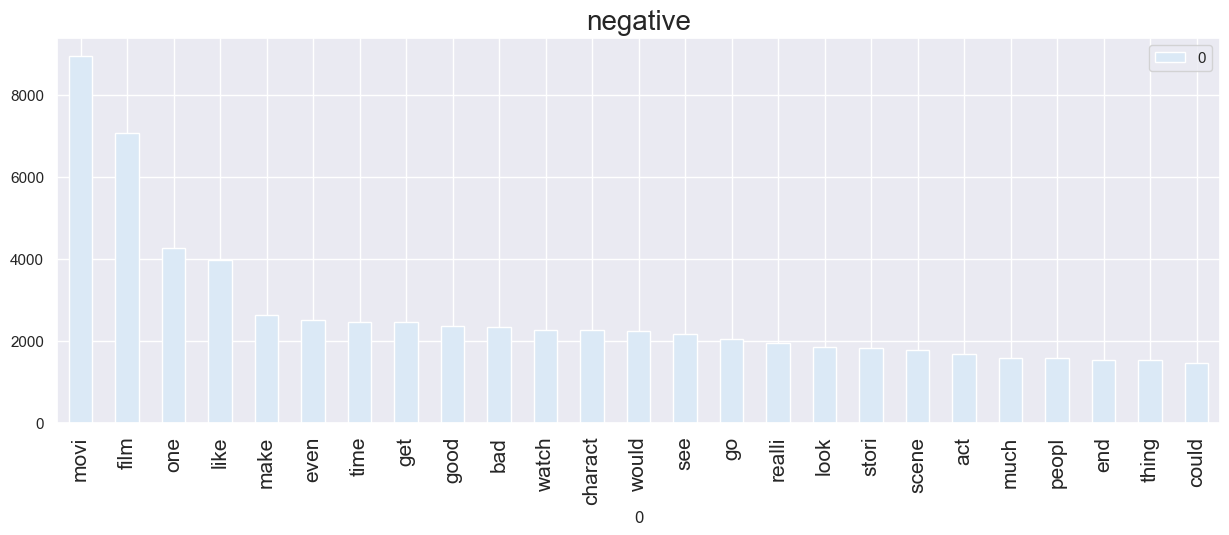

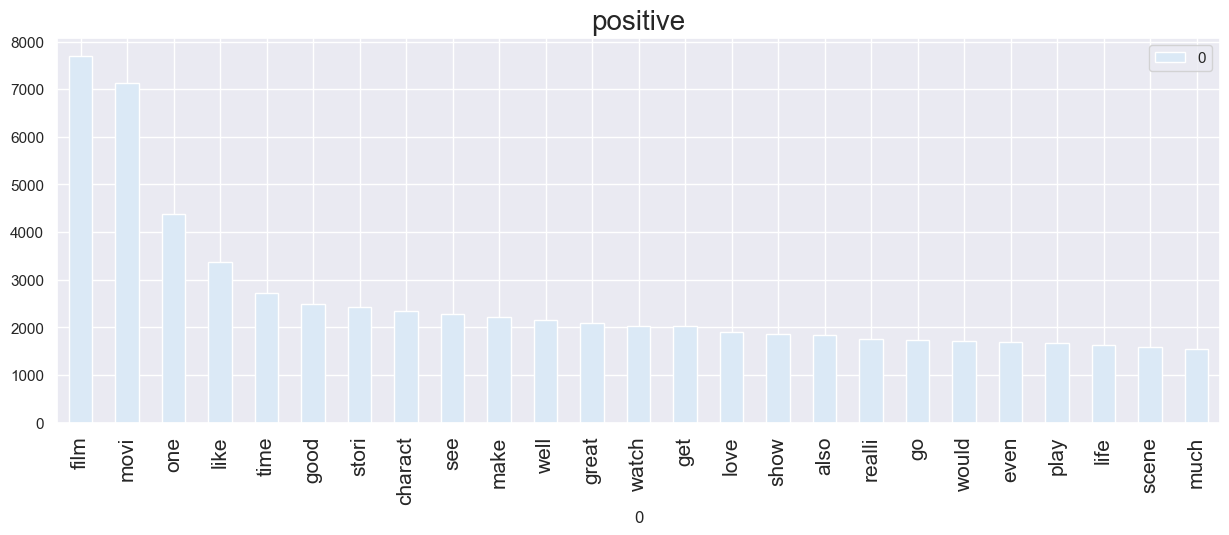

In [23]:
df = pd.DataFrame({"text": dataset[0:len(training_set)].clean_review, "CLASS": dataset[0:len(training_set)].sentiment})
grouped = df.groupby(["CLASS"]).apply(lambda x: x["text"].sum())
grouped_df = pd.DataFrame({"CLASS": grouped.index, "text": grouped.values})

from nltk.tokenize import WhitespaceTokenizer
tokenizer = WhitespaceTokenizer()

for ii, text in enumerate(grouped_df.text):
    pd.DataFrame(tokenizer.tokenize(text)).apply(pd.value_counts).head(25).plot(kind="bar")
    plt.title(grouped_df.CLASS[ii], fontsize=20)
    plt.xticks(fontsize=15)
    interactive(True)
    plt.show()

Las palabras que se muestran ahora tienen más significado. Vemos que por ejemplo, **love** es bastante frecuente en las reviews positivas y **bad** en las negativas.

In [24]:
X_train = dataset[0:len(training_set)][["id", "clean_review", "clean_review_only_letters", "clean_review_v2"]]
y_train = dataset[0:len(training_set)][["sentiment"]]

X_test = dataset[len(training_set):len(dataset)][["id", "clean_review", "clean_review_only_letters", "clean_review_v2"]]
y_test = dataset[len(training_set):len(dataset)][["sentiment"]]

Ahora mismo las etiquetas son strings 'positive' y 'negative'. Vamos a convertirlas a 1 y 0.

In [25]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
print(f"Values before encoding: {y_train.sentiment.values}")
le.fit(y_train.sentiment.values)
target_labels = le.classes_
encoded_y_train = le.transform(y_train.sentiment.values)
print(f"Labels after encoding: {encoded_y_train}")

print(f"Target labels: {target_labels}")

Values before encoding: ['negative' 'positive' 'negative' ... 'negative' 'negative' 'negative']
Labels after encoding: [0 1 0 ... 0 0 0]
Target labels: ['negative' 'positive']


Negative -> 0
Positive -> 1

In [26]:
print(encoded_y_train)
print(encoded_y_train.shape)

[0 1 0 ... 0 0 0]
(8000,)


**Modelo de espacio vectorial**

Vamos a aplicar una representación de bolsa de palabras (Bag of Words, BoW).

In [27]:
count_vect = CountVectorizer(analyzer = "word")

train_features = count_vect.fit_transform(X_train.clean_review)
test_features = count_vect.transform(X_test.clean_review)

In [28]:
# Observemos el vocabulario
print('Longitud del vocabulario: ')
print(len(count_vect.vocabulary_))
print()
print("Observemos el vocabulario:")
print(count_vect.vocabulary_)
print()


Longitud del vocabulario: 
31735

Observemos el vocabulario:
{'peopl': 20898, 'tri': 28729, 'make': 17066, 'believ': 2887, 'premis': 21804, 'rubbishi': 23853, 'supernatur': 27235, 'horror': 13271, 'thriller': 28143, 'inspir': 14112, 'actual': 740, 'last': 15892, 'word': 31187, 'spoken': 26354, 'authent': 2150, 'serial': 24880, 'killer': 15293, 'whose': 30904, 'name': 19016, 'escap': 9325, 'moment': 18458, 'whilst': 30826, 'await': 2215, 'execut': 9540, 'electr': 8906, 'chair': 4981, 'claim': 5482, 'soul': 26123, 'would': 31238, 'return': 23288, 'life': 16262, 'continu': 6184, 'go': 11604, 'never': 19274, 'end': 9107, 'murder': 18859, 'spree': 26397, 'highli': 12963, 'origin': 20100, 'idea': 13604, 'revolv': 23327, 'film': 10133, 'way': 30639, 'low': 16686, 'budget': 4129, 'turkey': 28950, 'implement': 13764, 'exact': 9496, 'basic': 2636, 'like': 16297, 'hous': 13333, 'shocker': 25215, 'ghost': 11359, 'machin': 16901, 'anyway': 1614, 'first': 10224, 'power': 21701, 'pentagram': 20893, '

In [29]:
# Ejemplo original de una review
print("Original:")
print(dataset.review.head()[0])
print()

# Ejemplo tras el preprocesado
print("Pre-procesado:")
print(X_train.clean_review[0])
print()

# Convertimos la primera review
v0 = count_vect.transform([X_train.clean_review[0]]).toarray()[0]
print('Convertido: ')
print(v0)
print()

# Es demasiado grande para observarlo, imprimimos su longitud
print('Longitud del vector: ')
print(len(v0))
print()

# ¿Cuántas palabras contiene la frase?
print('Número de palabras: ')
print(np.sum(v0))
print()


Original:
People tried to make me believe that the premise of this rubbishy supernatural horror/thriller was inspired by the actual last words spoken by an authentic serial killer (whose name escapes me at the moment). Whilst awaiting his execution in the electric chair, he claimed that his soul would return to life and continue to go on a never-ending murder spree. It's not a highly original idea to revolve a horror film on, by the way. Other low-budget turkeys implemented the exact same basic premise, like "House 3", "Shocker" and "Ghost in the Machine". Anyway, "The First Power" (a.k.a "Pentagram") isn't a completely terrible effort, but the script overly reverts to clichés and lacks genuine thrills. The film starts off as an okay, albeit mundane serial killer flick in which obsessive cop-hero Lou Diamond Philips pursues a maniac who carves bloody pentagrams into the chests of his victims. He receives unexpected help from a spiritual medium, played by the gorgeous and underrated Tra

**Reutilizamos las funciones de la práctica guiada**

In [30]:
import numpy as np
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate a simple plot of the test and traning learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : integer, cross-validation generator, optional
        If an integer is passed, it is the number of folds (defaults to 3).
        Specific cross-validation objects can be passed, see
        sklearn.cross_validation module for the list of possible objects
    """
    
    plt.figure()
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=1, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid("on") 
    if ylim:
        plt.ylim(ylim)
    plt.title(title)

In [31]:
def train_and_evaluate_classifier(X, yt, estimator, grid):
    """Train and Evaluate a estimator (defined as input parameter) on the given labeled data using accuracy."""

    # Se realiza validación cruzada sobre el clasificador seleccionado
    from sklearn.model_selection import ShuffleSplit
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

    from sklearn.model_selection import GridSearchCV
    classifier = GridSearchCV(estimator=estimator, cv=cv,  param_grid=grid, error_score=0.0, n_jobs = -1, verbose = 5)
    
    # Entrenamiento
    print("Training model")
    classifier.fit(X, yt)

    # Puntuación de la validación cruzada
    from sklearn.model_selection import cross_val_score
    print("CV-scores for each grid configuration")
    means = classifier.cv_results_['mean_test_score']
    stds = classifier.cv_results_['std_test_score']
    for mean, std, params in sorted(zip(means, stds, classifier.cv_results_['params']), key=lambda x: -x[0]):
        print("Accuracy: %0.3f (+/-%0.03f) for params: %r" % (mean, std * 2, params))
    print()
        
    # Curva de aprendizaje
    print("Learning curve for the best estimator")
    title = 'Learning Curves (' + str(estimator.__class__).replace("'>", "").split(".")[-1] + ' )'
    plot_learning_curve(classifier.best_estimator_, title, X, yt, cv=cv)
    plt.show()
    
    return classifier

In [31]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    import itertools
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# Entrenamiento de algoritmos de aprendizaje automático clásicos

### Primer clasificador: Naive Bayes

Training model
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 5/5] END ..................................., score=0.849 total time=   0.1s
[CV 3/5] END ..................................., score=0.852 total time=   0.1s
[CV 4/5] END ..................................., score=0.853 total time=   0.1s
[CV 2/5] END ..................................., score=0.846 total time=   0.1s
[CV 1/5] END ..................................., score=0.831 total time=   0.1s
CV-scores for each grid configuration
Accuracy: 0.846 (+/-0.016) for params: {}

Learning curve for the best estimator


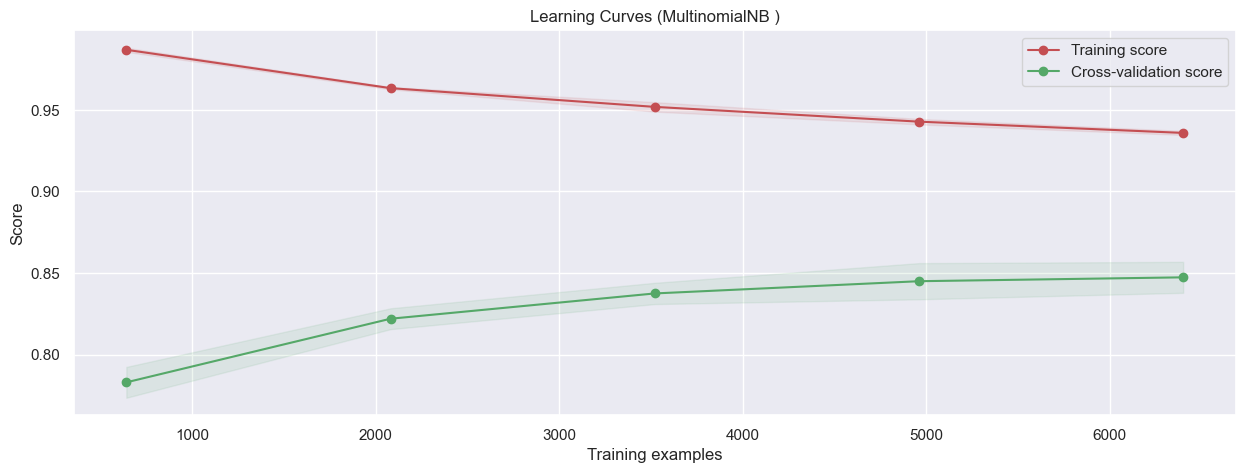

In [33]:
from sklearn.naive_bayes import MultinomialNB

#En este caso no hace falta optimizar ningún parámetro
nb_grid= {} 

nb_text_cls = train_and_evaluate_classifier(train_features, encoded_y_train, MultinomialNB(), nb_grid)

In [34]:
print("Predicting on the test set")
y_pred = nb_text_cls.predict(test_features)

y_pred = le.inverse_transform(y_pred)

Predicting on the test set


Classification Report
              precision    recall  f1-score   support

    negative       0.83      0.86      0.85      1025
    positive       0.85      0.82      0.84       975

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000

Confusion matrix, without normalization


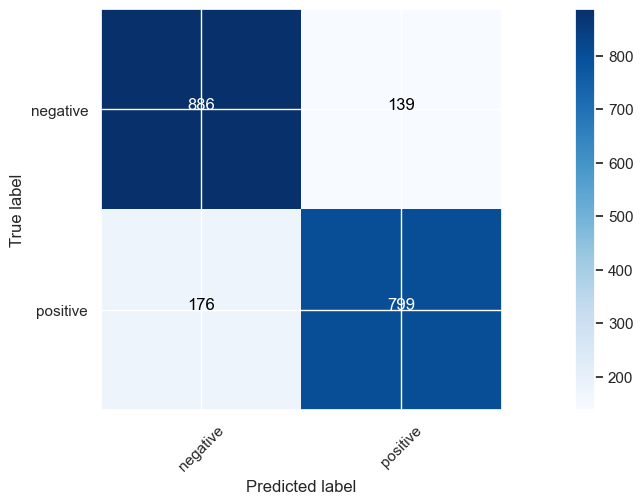

Final Accuracy
0.8425


In [35]:
print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred,))

### Segundo clasificador: SVM

Training model
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 2/5] END ...............C=10, kernel=linear;, score=0.825 total time=  35.0s
[CV 2/5] END ................C=1, kernel=linear;, score=0.826 total time=  35.5s
[CV 5/5] END ................C=1, kernel=linear;, score=0.819 total time=  35.6s
[CV 4/5] END ................C=1, kernel=linear;, score=0.838 total time=  35.6s
[CV 3/5] END ................C=1, kernel=linear;, score=0.831 total time=  35.6s
[CV 1/5] END ...............C=10, kernel=linear;, score=0.814 total time=  36.8s
[CV 3/5] END ...............C=10, kernel=linear;, score=0.831 total time=  36.8s
[CV 1/5] END ................C=1, kernel=linear;, score=0.814 total time=  36.9s
[CV 2/5] END ..............C=100, kernel=linear;, score=0.825 total time=  39.7s
[CV 5/5] END ...............C=10, kernel=linear;, score=0.819 total time=  39.9s
[CV 4/5] END ...............C=10, kernel=linear;, score=0.838 total time=  40.9s
[CV 3/5] END ..............C=100, 

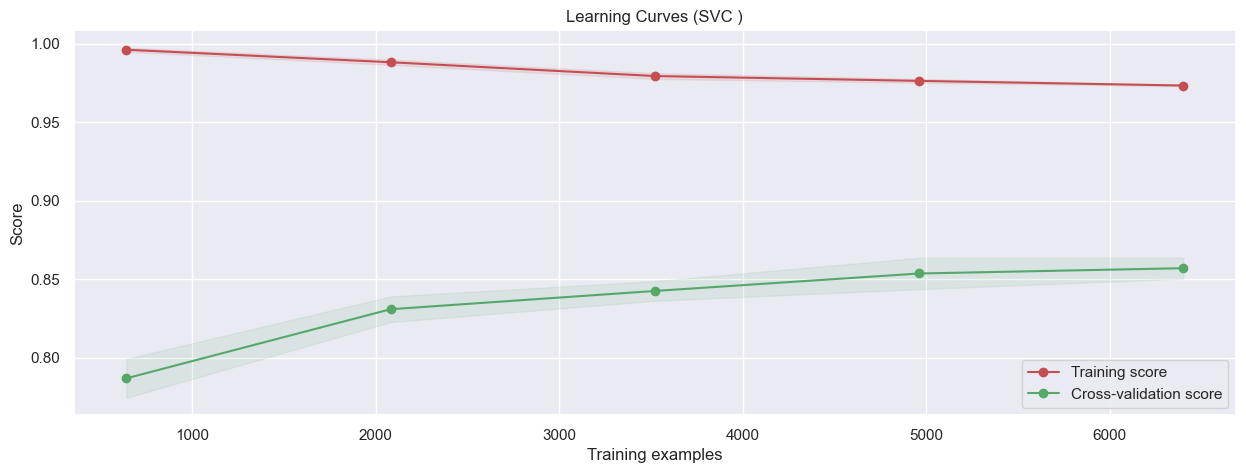

In [37]:
# SVM
from sklearn.svm import SVC

svm_grid = [
  {'C': [1, 10, 100], 'kernel': ['linear']},
  {'C': [10, 100, 1000], 'gamma': [0.0001], 'kernel': ['rbf']},
 ]

svm_cls = train_and_evaluate_classifier(train_features, encoded_y_train, SVC(), svm_grid)

La exploración de SVM tardó unos 10 minutos en la CPU de mi máquina, prácticamente un orden de magnitud más que Naive Bayes.

In [38]:
print("Best estimator found by grid search:")
print(svm_cls.best_estimator_)

Best estimator found by grid search:
SVC(C=100, gamma=0.0001)


In [ ]:
print("Predicting sentiment reviews on the test set")
y_pred = svm_cls.predict(test_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting fake news on the test set


Classification Report
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      1025
    positive       0.85      0.87      0.86       975

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion matrix, without normalization


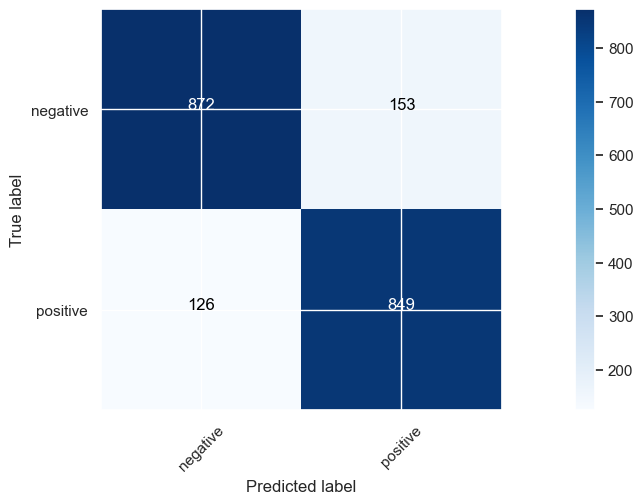

Final Accuracy
0.8605


In [40]:
print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred,))

### Tercer clasificador: MaxEnt

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.508 total time=   0.2s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.516 total time=   0.2s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.497 total time=   0.2s
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.491 total time=   0.2s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.507 total time=   0.2s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.843 total time=   0.3s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.819 total time=   0.3s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.827 total time=   0.3s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.819 total time=   0.2s
[CV 1/5] END ................C=0.01, penalty=l1;, score=0.730 total time=   0.2s
[CV 4/5] END ................C=0.01, penalty=l1;, score=0.756 total time=   0.2s[CV 4/5] END ...............C=0.00

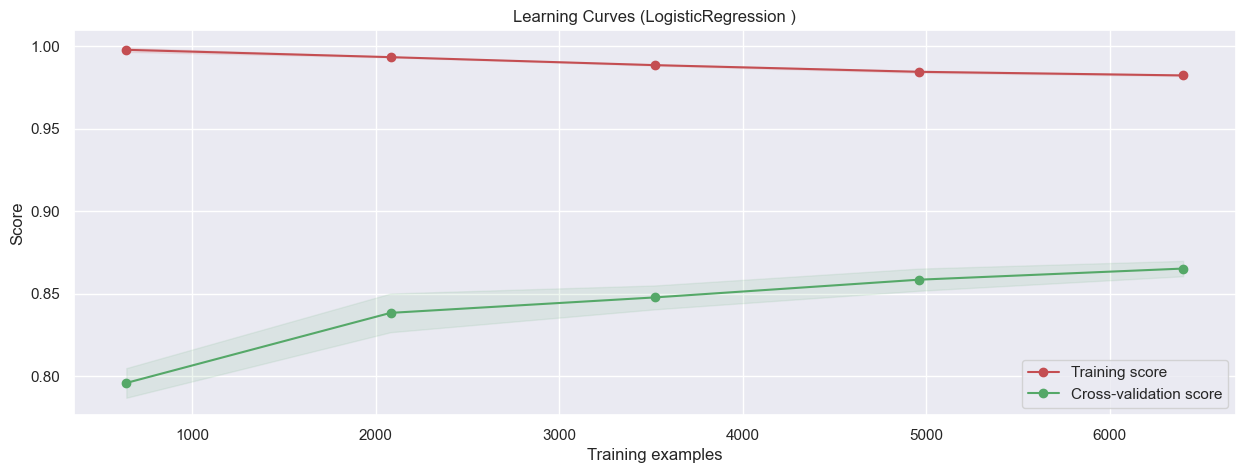

In [47]:
from sklearn.linear_model import LogisticRegression
max_ent_grid= {'penalty': ['l1','l2'], 'C': [0.001,0.01,0.1,1,10,100,1000]}
max_ent_cls = train_and_evaluate_classifier(train_features, encoded_y_train, LogisticRegression(solver='liblinear'), max_ent_grid)

In [48]:
print("Best estimator found by grid search:")
print(max_ent_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=0.1, solver='liblinear')


In [ ]:
print("Predicting sentiment on the test set")
y_pred = max_ent_cls.predict(test_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting fake news on the test set


Both training and inference is faster in MaxEnt than in SVM.

Classification Report
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      1025
    positive       0.85      0.87      0.86       975

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion matrix, without normalization


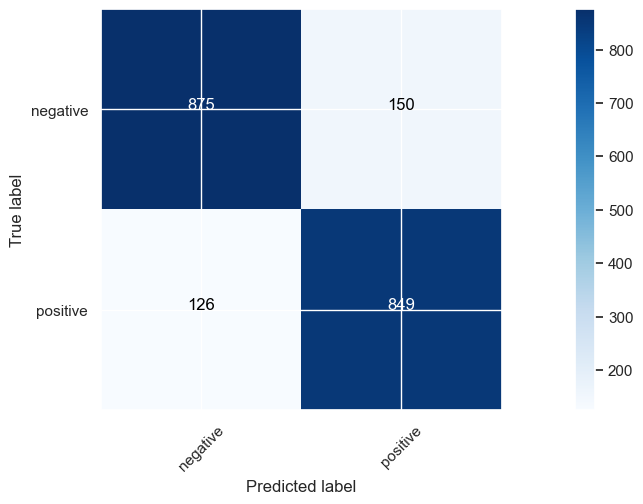

Final Accuracy
0.862


In [50]:
print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

### Cuarto clasificador: Random Forest

Training model
Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV 1/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.817 total time=  31.7s
[CV 4/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.846 total time=  31.9s
[CV 5/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.842 total time=  31.9s
[CV 3/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.846 total time=  32.1s
[CV 2/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.842 total time=  32.2s
[CV 1/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300;, score=0.833 total time= 1.4min
[CV 3/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300;, score=0.850 total time= 1.4min
[CV 2/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=

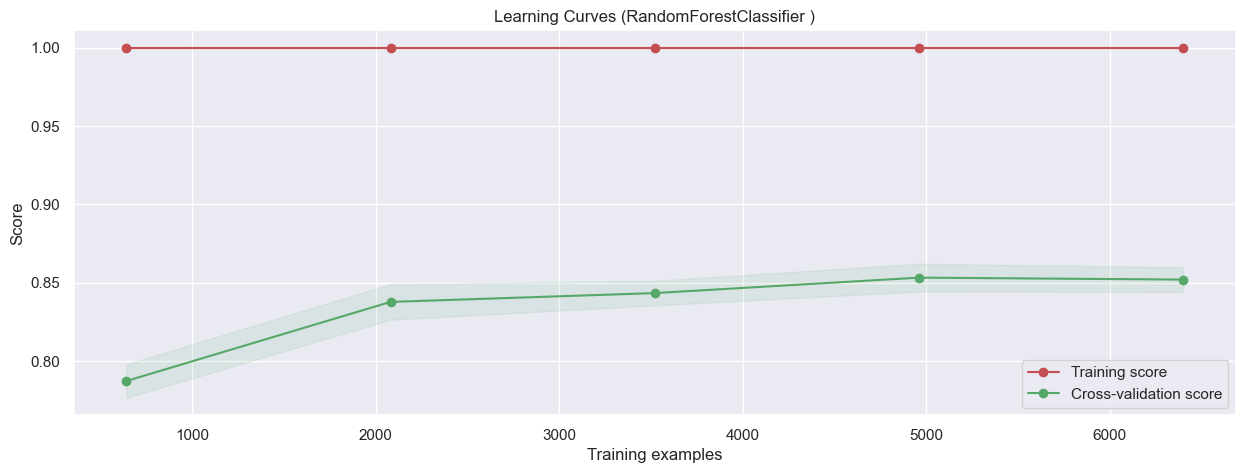

In [ ]:
from sklearn.ensemble import RandomForestClassifier

train_features = count_vect.fit_transform(X_train.clean_review)
test_features = count_vect.transform(X_test.clean_review)

rf_grid = {
    "n_estimators": [100, 300, 500],  # Número de árboles
    "max_depth": [None, 20, 50],  # Profundidad máxima de los árboles
    "min_samples_split": [2, 5, 10],  # Mínimo número de muestras para dividir un nodo
    "min_samples_leaf": [1, 2, 4]  # Mínimo número de muestras en una hoja
}

rf_cls = train_and_evaluate_classifier(
    train_features,
    encoded_y_train,
    RandomForestClassifier(random_state=42),
    rf_grid
)

In [101]:
print("Predicting fake news on the test set")
y_pred = rf_cls.predict(test_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting fake news on the test set


Classification Report
              precision    recall  f1-score   support

    negative       0.87      0.83      0.85      1025
    positive       0.83      0.86      0.85       975

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Confusion matrix, without normalization


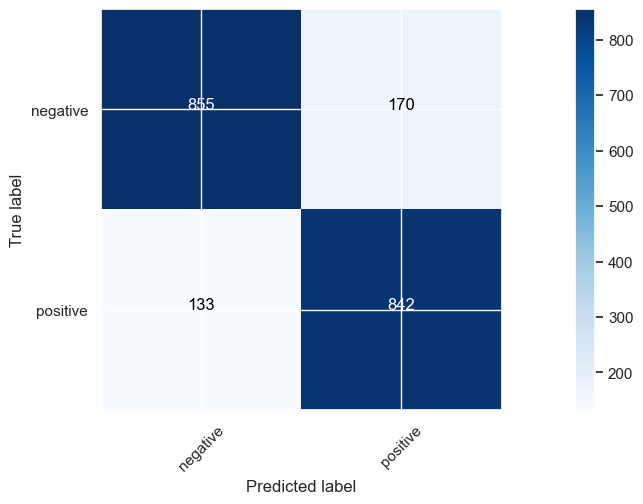

Final Accuracy
0.8485


In [102]:
print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

Para el mismo preprocesado de texto, obtenemos lo siguiente:
- Naive Bayes: 84,25% accuracy
- SVM: 86,05% accuracy
- MaxEnt: 86,20% accuracy
- Random Forest: 84,85% accuracy

Nos quedamos con MaxEnt como el mejor clasificador. Su exploración es más rápida que la de SVM. Ahora vamos a comparar distintas configuraciones de pre-procesado 
con el mismo clasificador.

### Pre-procesado: Eliminando números

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.819 total time=   0.3s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.516 total time=   0.3s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.507 total time=   0.4s
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.491 total time=   0.4s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.497 total time=   0.4s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.508 total time=   0.4s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.844 total time=   0.4s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.830 total time=   0.4s
[CV 4/5] END ................C=0.01, penalty=l1;, score=0.756 total time=   0.2s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.841 total time=   0.3s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.821 total time=   0.3s
[CV 2/5] END ................C=0.

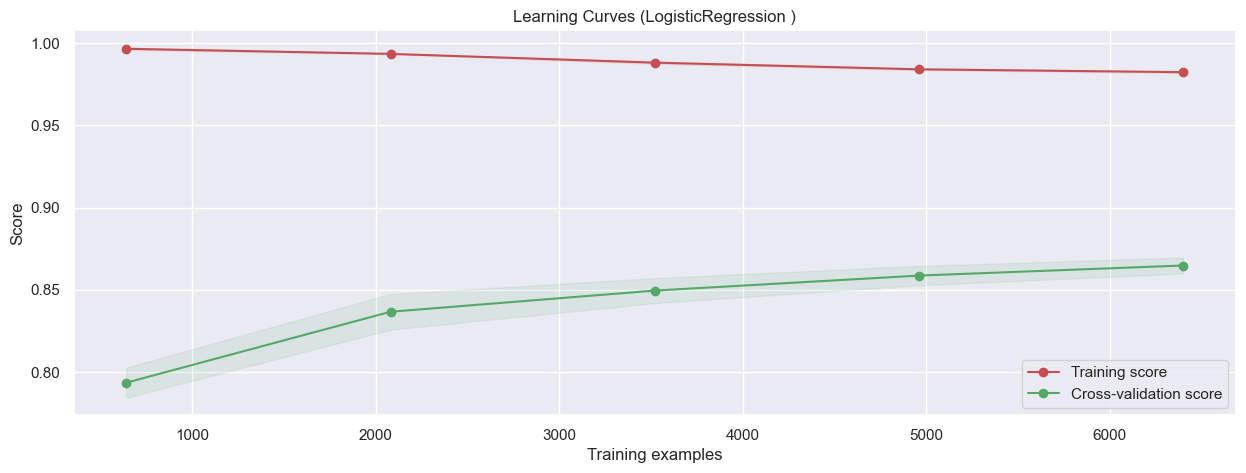

In [58]:
from sklearn.linear_model import LogisticRegression
train_features = count_vect.fit_transform(X_train.clean_review_only_letters)
test_features = count_vect.transform(X_test.clean_review_only_letters)
max_ent_grid= {'penalty': ['l1','l2'], 'C': [0.001,0.01,0.1,1,10,100,1000]}
max_ent_cls = train_and_evaluate_classifier(train_features, encoded_y_train, LogisticRegression(solver='liblinear'), max_ent_grid)

In [59]:
print("Predicting fake news on the test set")
y_pred = max_ent_cls.predict(test_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting fake news on the test set


Classification Report
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      1025
    positive       0.85      0.87      0.86       975

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion matrix, without normalization


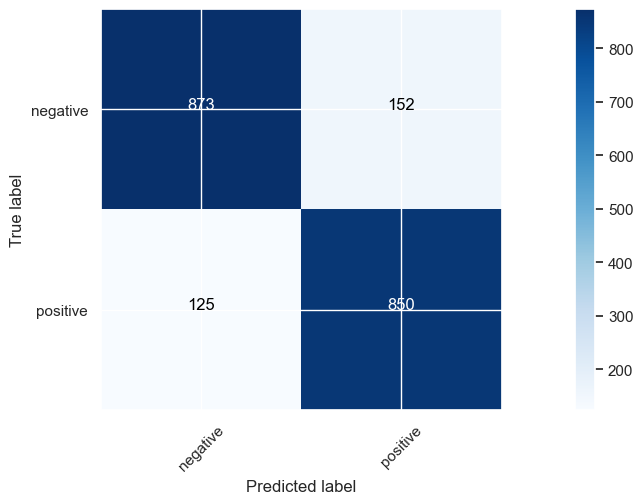

Final Accuracy
0.8615


In [60]:
print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

### Pre-procesado: Manteniendo números y negaciones

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.516 total time=   0.4s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.497 total time=   0.4s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.508 total time=   0.4s
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.491 total time=   0.4s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.507 total time=   0.4s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.834 total time=   0.5s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.815 total time=   0.5s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.808 total time=   0.5s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.831 total time=   0.3s
[CV 1/5] END ................C=0.01, penalty=l1;, score=0.718 total time=   0.3s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.807 total time=   0.3s
[CV 3/5] END ................C=0.

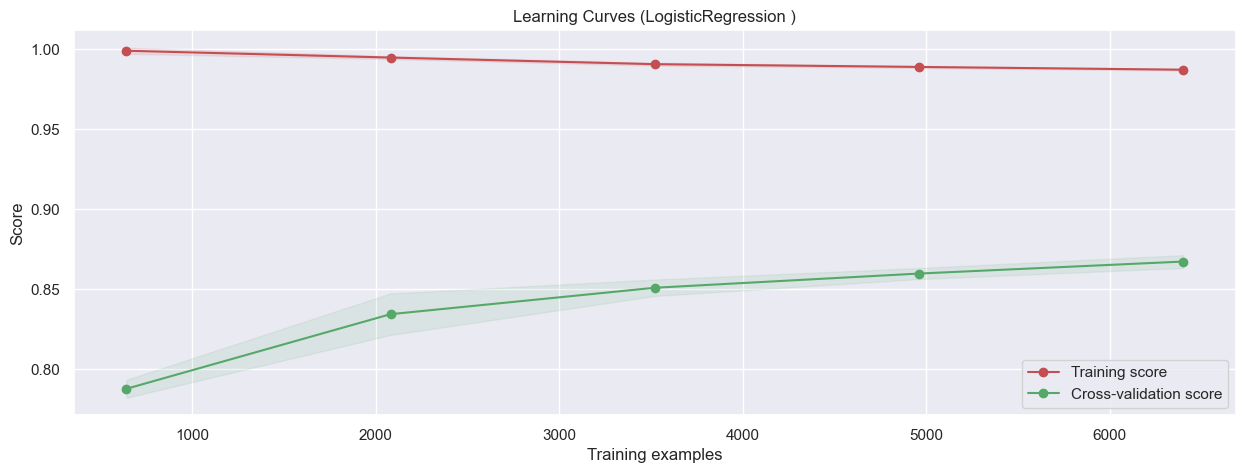

In [86]:
from sklearn.linear_model import LogisticRegression
train_features = count_vect.fit_transform(X_train.clean_review_v2)
test_features = count_vect.transform(X_test.clean_review_v2)
max_ent_grid= {'penalty': ['l1','l2'], 'C': [0.001,0.01,0.1,1,10,100,1000]}
max_ent_cls = train_and_evaluate_classifier(train_features, encoded_y_train, LogisticRegression(solver='liblinear'), max_ent_grid)

In [ ]:
print("Predicting sentiment on the test set")
y_pred = max_ent_cls.predict(test_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting fake news on the test set


Classification Report
              precision    recall  f1-score   support

    negative       0.88      0.86      0.87      1025
    positive       0.86      0.88      0.87       975

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Confusion matrix, without normalization


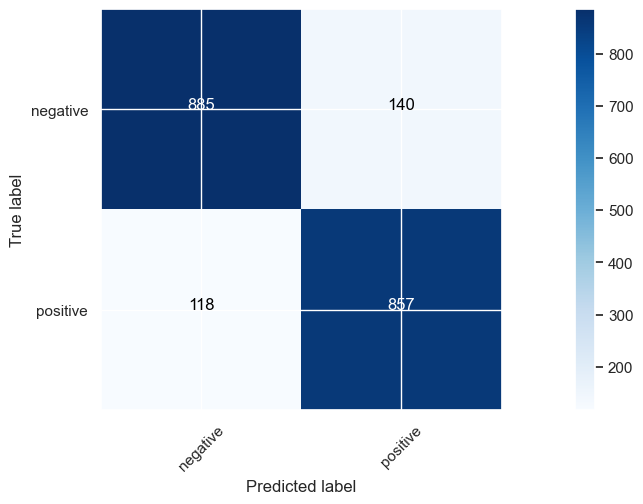

Final Accuracy
0.871


In [88]:
print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

### Resultados sobre combinaciones de pre-procesado
Estos son las pruebas y resultados obtenidos para distintas combinaciones de pre-procesado con el clasificador MaxEnt en una representación BoW:
- Con números y sin negaciones: 86,20%
- Sin números y sin negaciones: 86,15%
- Con números y con negaciones: 87,10%

Nos quedamos entonces con la última configuración, usando la función **process_text_v2** y MaxEnt como clasificador.
Mantener los números y las negaciones tiene el riesgo de añadir ruido en los datos, pero las mantengo en este caso porque mejoran en este experimento.

### Pesado con TF-IDF

Ahora vamos a intentar mejorar el peso específico de cada término aplicando TF-IDF. Con un pesado más preciso, la representación de los datos es también más precisa, y por tanto debería mejorar los resultados del clasificador.

In [89]:
from sklearn.feature_extraction.text import TfidfTransformer

X_train["all"] = X_train[['clean_review_v2']].apply(lambda x: ''.join(x), axis=1)
X_test["all"] = X_test[['clean_review_v2']].apply(lambda x: ''.join(x), axis=1)

count_vect = CountVectorizer(analyzer = "word")
train_features = count_vect.fit_transform(X_train['all'])
test_features = count_vect.transform(X_test['all'])

# Se utiliza L2 (norma euclídea) para normalizar los vectores resultantes
tfidf = TfidfTransformer(norm="l2")
train_text_tfidf_features = tfidf.fit_transform(train_features)
test_text_tfidf_features = tfidf.transform(test_features)                


Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits


[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.602 total time=   0.2s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.764 total time=   0.2s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.497 total time=   0.2s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.508 total time=   0.2s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.516 total time=   0.2s
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.491 total time=   0.2s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.507 total time=   0.2s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.792 total time=   0.3s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.526 total time=   0.1s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.621 total time=   0.1s
[CV 1/5] END ................C=0.01, penalty=l1;, score=0.491 total time=   0.1s
[CV 4/5] END ................C=0.01, penalty=l1;, score=0.507 total time=   0.2s
[CV 5/5] END ...............

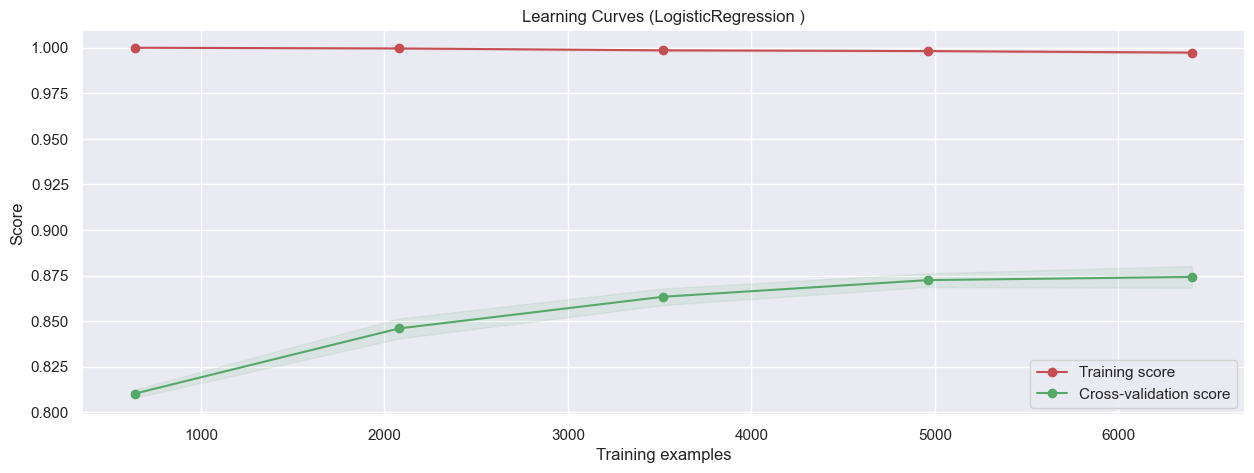

In [90]:
max_ent_tfidf_cls = train_and_evaluate_classifier(train_text_tfidf_features, encoded_y_train, LogisticRegression(solver='liblinear'), max_ent_grid)

In [92]:
print("Best estimator found by grid search:")
print(max_ent_tfidf_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=10, solver='liblinear')


In [ ]:
print("Predicting sentiment reviews on the test set")
y_pred = max_ent_tfidf_cls.predict(test_text_tfidf_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting fake news on the test set


Classification Report
              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      1025
    positive       0.87      0.89      0.88       975

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion matrix, without normalization


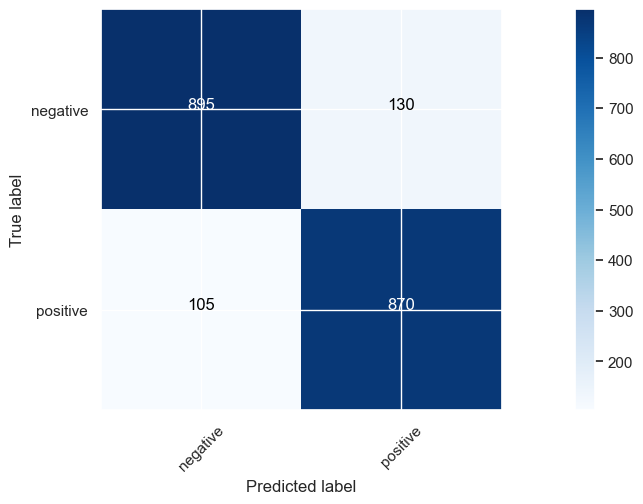

Final Accuracy
0.8825


In [94]:
print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

La representación TF-IDF mejora de 87,10% a 88,25%.
Ahora muestro las ocurrencias de las 20 palabras más frecuentes en las reviews negativas y positivas.

In [104]:
count_vect = CountVectorizer(analyzer = "word") # set min_df = frequency
dataset['all'] = pd.concat([X_train, X_test], ignore_index=True)['clean_review_v2']
negative_features = count_vect.fit_transform(dataset[np.array(pd.concat([pd.concat([X_train, X_test], ignore_index=True), pd.concat([y_train, y_test], ignore_index=True)], axis=1).sentiment == "negative")]['all'])

negative_occ = np.asarray(negative_features.sum(axis=0)).ravel().tolist()

counts_df = pd.DataFrame({'term': count_vect.get_feature_names_out(), 'occurrences': negative_occ})
counts_df.sort_values(by='occurrences', ascending=False).head(20)

,term,occurrences
19035,not,13336
18238,movie,11278
10132,film,8991
19410,one,5540
16034,like,4567
30856,would,3484
28059,time,3166
18921,no,2979
9316,even,2975
11601,good,2955


In [105]:
positive_features = count_vect.fit_transform(dataset[np.array(pd.concat([pd.concat([X_train, X_test], ignore_index=True), pd.concat([y_train, y_test], ignore_index=True)], axis=1).sentiment == "positive")]['all'])
positive_occ = np.asarray(positive_features.sum(axis=0)).ravel().tolist()

counts_df = pd.DataFrame({'term': count_vect.get_feature_names_out(), 'occurrences': positive_occ})
counts_df.sort_values(by='occurrences', ascending=False).head(20)

,term,occurrences
19764,not,11102
10502,film,9479
18987,movie,9453
20164,one,5621
16659,like,3821
29087,time,3327
12039,good,3108
27581,story,2942
4575,character,2888
32033,would,2807


Ahora muestro los pesos TF-IDF de las 20 palabras conmayor peso en las reviews negativas y positivas.

In [96]:
transformer = TfidfTransformer()
fake_features = count_vect.fit_transform(dataset[np.array(pd.concat([pd.concat([X_train, X_test], ignore_index=True), pd.concat([y_train, y_test], ignore_index=True)], axis=1).sentiment == "negative")]['all'])
transformed_weights = transformer.fit_transform(fake_features)

weights = np.asarray(transformed_weights.mean(axis=0)).ravel().tolist()
weights_df = pd.DataFrame({'term': count_vect.get_feature_names_out(), 'weight': weights})
weights_df.sort_values(by='weight', ascending=False).head(20)

,term,weight
18238,movie,0.058022
19035,not,0.052417
10132,film,0.044676
19410,one,0.027865
16034,like,0.025042
1909,bad,0.021583
30856,would,0.021225
11601,good,0.020606
28059,time,0.019970
18921,no,0.019209


In [106]:
positive_features = count_vect.fit_transform(dataset[np.array(pd.concat([pd.concat([X_train, X_test], ignore_index=True), pd.concat([y_train, y_test], ignore_index=True)], axis=1).sentiment == "positive")]['all'])
transformed_weights = transformer.fit_transform(positive_features)

weights = np.asarray(transformed_weights.mean(axis=0)).ravel().tolist()
weights_df = pd.DataFrame({'term': count_vect.get_feature_names_out(), 'weight': weights})
weights_df.sort_values(by='weight', ascending=False).head(20)

,term,weight
18987,movie,0.052328
10502,film,0.044694
19764,not,0.044020
20164,one,0.027141
16659,like,0.022176
12039,good,0.020805
29087,time,0.019875
27581,story,0.019357
12245,great,0.018150
32033,would,0.017873


### Selección de características

Chi-Squared: Vamos a realizar un proceso de selección de las características más relevantes utilizando Chi-Squared. Se trata de un test estadístico que nos permite determinar si una característica concreta tiene una elevada correlación con la clase final, según el conjunto de entrenamiento. Utilizando este método, podemos quedarnos con las "n" características con mayores valores de Chi-Squared.


In [107]:
tfidf = TfidfVectorizer(norm="l2")
train_text_tfidf_features = tfidf.fit_transform(X_train.clean_review_v2)
test_text_tfidf_features = tfidf.transform(X_test.clean_review_v2)

feature_names = tfidf.get_feature_names_out()
ch2 = SelectKBest(chi2, k=5000)
train_text_tfidf_ch2_features = ch2.fit_transform(train_text_tfidf_features, y_train)
test_text_tfidf_ch2_features = ch2.transform(test_text_tfidf_features)
selected_feature_names = [feature_names[i] for i in ch2.get_support(indices=True)]

Las características se reducen de 41190 a 5000.

In [108]:
print("Features reduced from ", len(feature_names), "to", len(selected_feature_names))

Features reduced from  41190 to 5000


Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits


[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.601 total time=   0.1s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.516 total time=   0.1s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.799 total time=   0.1s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.507 total time=   0.1s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.767 total time=   0.1s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.497 total time=   0.1s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.508 total time=   0.1s
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.491 total time=   0.1s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.622 total time=   0.0s
[CV 1/5] END ................C=0.01, penalty=l1;, score=0.491 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.526 total time=   0.0s
[CV 4/5] END ................C=0.01, penalty=l1;, score=0.507 total time=   0.0s
[CV 2/5] END ...............

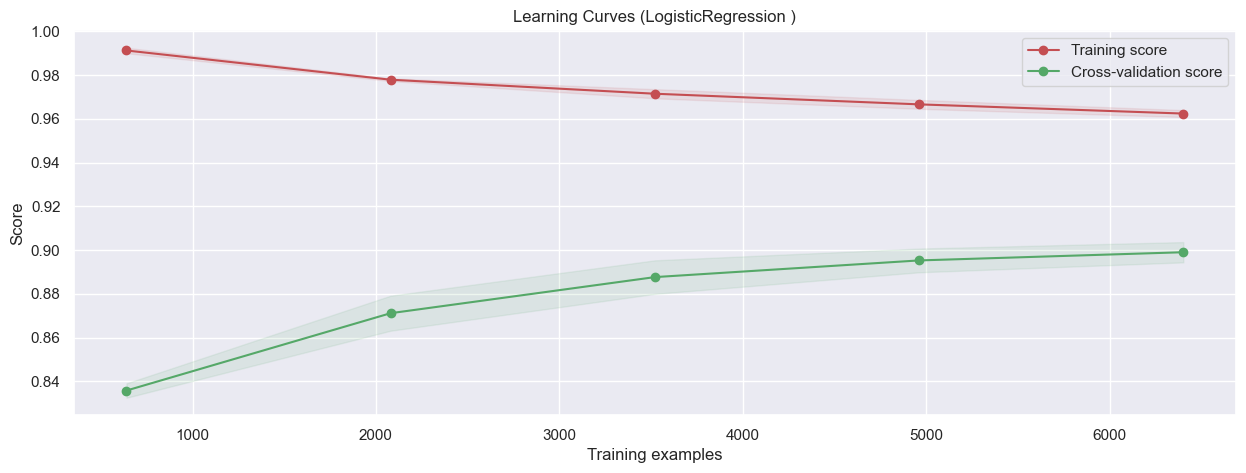

In [109]:
max_ent_chi2_cls = train_and_evaluate_classifier(train_text_tfidf_ch2_features, encoded_y_train, LogisticRegression(solver='liblinear'), max_ent_grid)

Predicting fake news on the test set
Classification Report
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      1025
    positive       0.86      0.89      0.87       975

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion matrix, without normalization


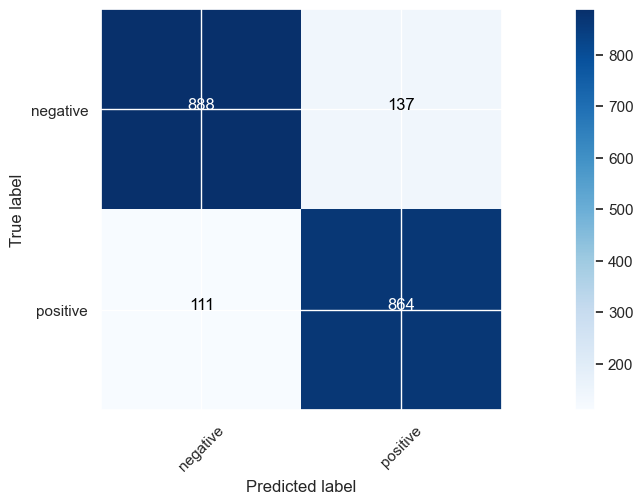

Final Accuracy
0.876


In [110]:
print("Predicting fake news on the test set")
y_pred = max_ent_chi2_cls.predict(test_text_tfidf_ch2_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)


print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

Reduciendo el tamaño del espacio de características a 5000, se obtiene una accuracy de 87,60%. Antes se obtuvo un 88,25%. Es algo peor, pero el modelo es más rápido de inferir.

### Conteo de bigramas

Normalmente la utilización de bigramas en lugar de unigramas tiende a mejorar los resultados de la clasificación. Los trigramas quizá no suelen proporcionar tanta mejora, pero también merece la pena considerarlos para algunas tareas concretas. Si el problema de clasificación lo requiere, se puede ir más allá (n-gramas).


In [111]:
bigram_count_vect = CountVectorizer(analyzer = "word", ngram_range=(1,2))
train_bigram_features = bigram_count_vect.fit_transform(X_train.clean_review_v2)
test_bigram_features = bigram_count_vect.transform(X_test.clean_review_v2)

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.507 total time=   1.1s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.497 total time=   1.2s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.516 total time=   1.2s
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.491 total time=   1.7s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.508 total time=   1.7s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.809 total time=   2.5s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.838 total time=   2.5s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.815 total time=   2.8s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.835 total time=   2.3s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.812 total time=   2.4s
[CV 3/5] END ................C=0.01, penalty=l1;, score=0.747 total time=   5.1s
[CV 1/5] END ................C=0.

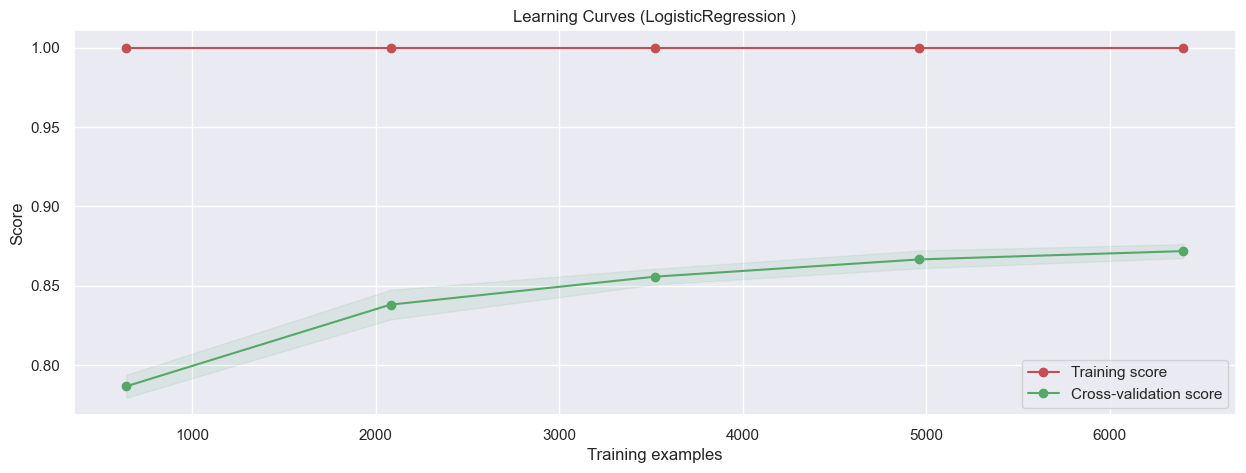

In [112]:
max_ent_bigram_cls = train_and_evaluate_classifier(train_bigram_features, encoded_y_train, LogisticRegression(solver='liblinear'), max_ent_grid)

This training took longer than unigram models.

In [113]:
print("Best estimator found by grid search:")
print(max_ent_bigram_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=10, solver='liblinear')


Predicting fake news on the test set
Classification Report
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      1025
    positive       0.87      0.88      0.87       975

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion matrix, without normalization


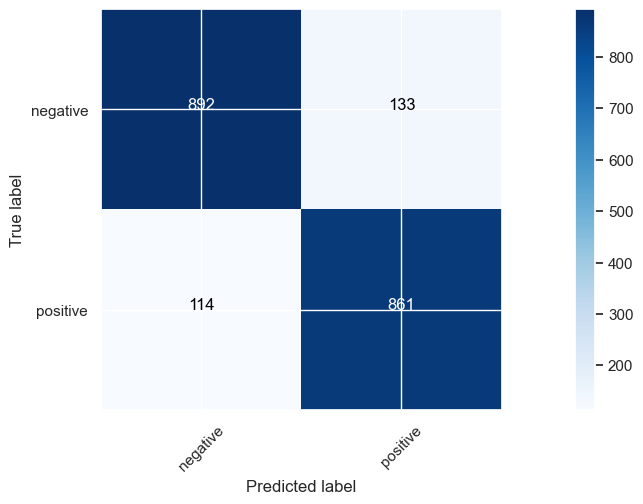

Final Accuracy
0.8765


In [114]:
print("Predicting fake news on the test set")
y_pred = max_ent_bigram_cls.predict(test_bigram_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)


print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

### BiGramas con TF-IDF

In [115]:
tfidf = TfidfTransformer(norm="l2")
train_text_bigram_tfidf_features = tfidf.fit_transform(train_bigram_features)
test_text_bigram_tfidf_features = tfidf.fit_transform(test_bigram_features)    

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.507 total time=   0.7s
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.491 total time=   0.7s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.508 total time=   0.7s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.497 total time=   0.8s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.516 total time=   0.8s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.492 total time=   0.9s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.612 total time=   0.9s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.693 total time=   1.2s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.484 total time=   0.7s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.493 total time=   0.7s
[CV 1/5] END ................C=0.01, penalty=l1;, score=0.491 total time=   0.7s
[CV 2/5] END ................C=0.

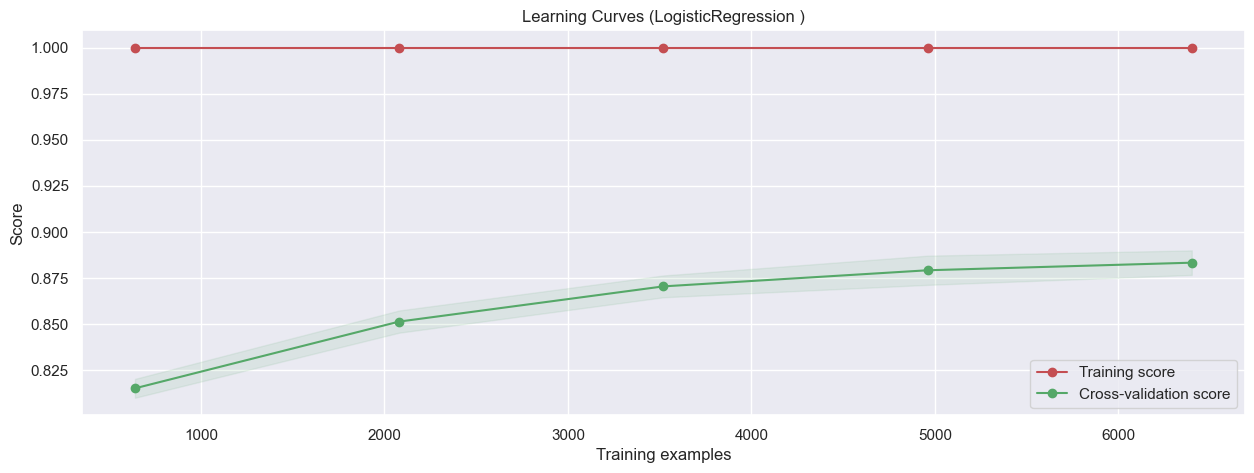

In [116]:
max_ent_tfidf_bigram_cls = train_and_evaluate_classifier(train_text_bigram_tfidf_features, encoded_y_train, LogisticRegression(solver='liblinear'), max_ent_grid)

In [117]:
print("Best estimator found by grid search:")
print(max_ent_tfidf_bigram_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=1000, solver='liblinear')


Predicting sentiment on the test set
Classification Report
              precision    recall  f1-score   support

    negative       0.90      0.87      0.89      1025
    positive       0.87      0.90      0.88       975

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

Confusion matrix, without normalization


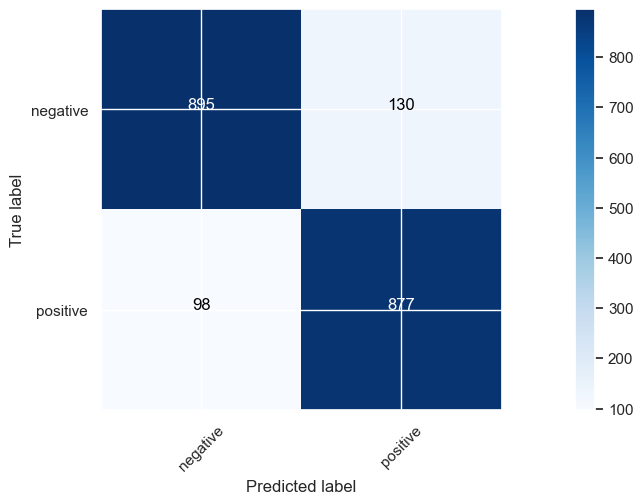

Final Accuracy
0.886


In [118]:
print("Predicting sentiment on the test set")
y_pred = max_ent_tfidf_bigram_cls.predict(test_text_bigram_tfidf_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)


print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

In [119]:
def most_informative_feature_for_binary_classification(vectorizer, classifier, n=100):
    """
    See: https://stackoverflow.com/a/26980472
    
    Identify most important features if given a vectorizer and binary classifier. Set n to the number
    of weighted features you would like to show. (Note: current implementation merely prints and does not 
    return top classes.)
    """

    class_labels = classifier.classes_
    feature_names = vectorizer.get_feature_names_out()
    topn_class1 = sorted(zip(feature_names, classifier.coef_[0]), key=lambda u: u[1])[:n]
    topn_class2 = sorted(zip(feature_names, classifier.coef_[0]), key=lambda u: -u[1])[:n]

    return topn_class1, topn_class2


In [120]:
# Remember negative is index 0 and positive is index 1
negative_features, positive_features = most_informative_feature_for_binary_classification(bigram_count_vect, max_ent_cls.best_estimator_, n=30)

<Axes: title={'center': 'Most important features to identify negative reviews'}, xlabel='feature'>

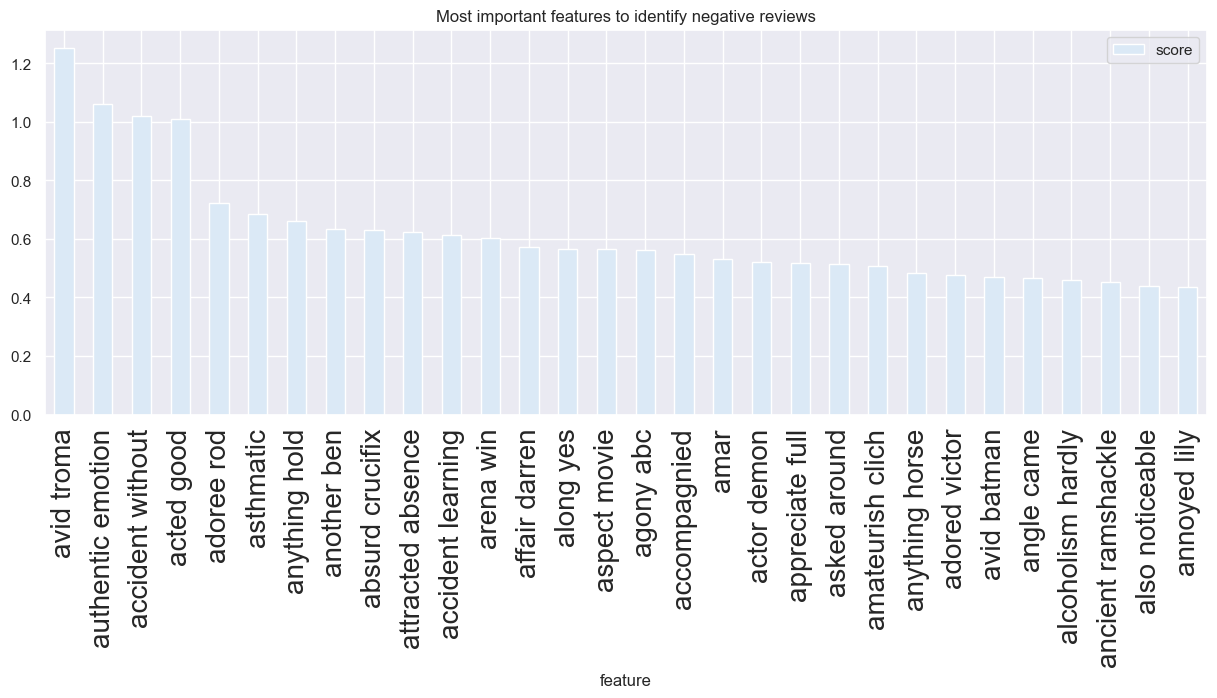

In [121]:
top_negative_features = pd.DataFrame(negative_features, columns=["feature", "score"])
top_negative_features.score = abs(top_negative_features.score)
plt.rc('xtick', labelsize=20)    # fontsize of the tick labels
top_negative_features.plot(x="feature", y="score", kind="bar", title="Most important features to identify negative reviews")

<Axes: title={'center': 'Most important features to identify positive reviews'}, xlabel='feature'>

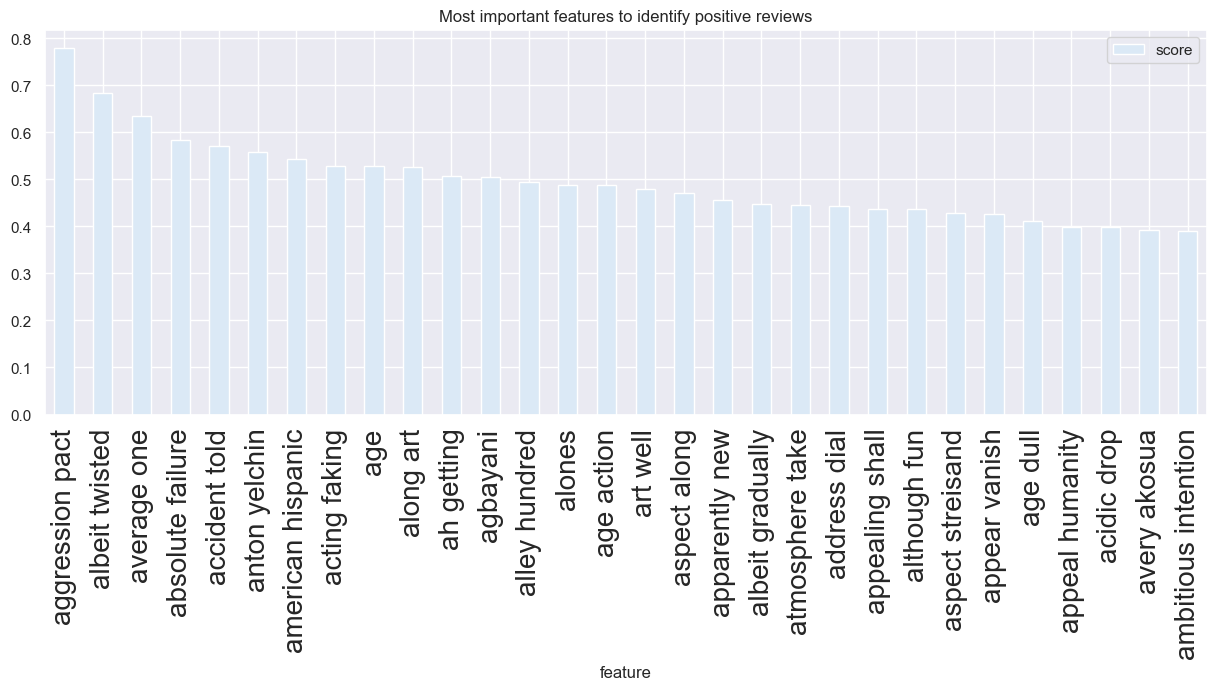

In [122]:
top_positive_features = pd.DataFrame(positive_features, columns=["feature", "score"])
plt.rc('xtick', labelsize=20)    # fontsize of the tick labels
top_positive_features.plot(x="feature", y="score", kind="bar", title="Most important features to identify positive reviews")

### Bigramas con TF-IDF y reducción de características a 5000

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.491 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.497 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.516 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.507 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.508 total time=   0.0s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.676 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.492 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.601 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.493 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.484 total time=   0.0s
[CV 1/5] END ................C=0.01, penalty=l1;, score=0.491 total time=   0.0s
[CV 3/5] END ................C=0.

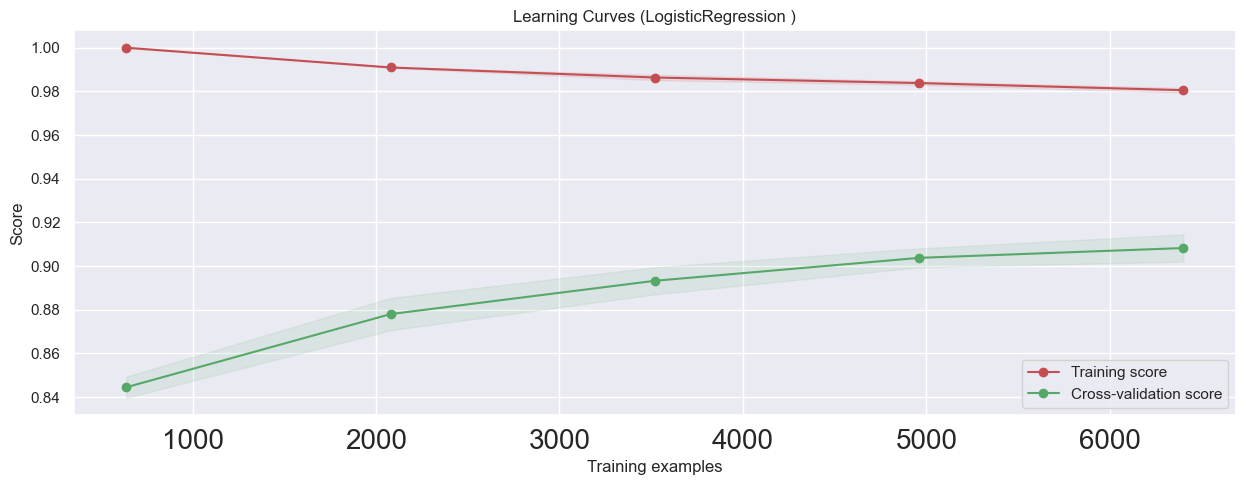

In [127]:
bigram_tfidf_chi2_vect = TfidfVectorizer(norm="l2", ngram_range=(1,2))
train_text_bigram_tfidf_chi2_features = bigram_tfidf_chi2_vect.fit_transform(X_train.clean_review_v2)
test_text_bigram_tfidf_chi2_features = bigram_tfidf_chi2_vect.transform(X_test.clean_review_v2)

ch2 = SelectKBest(chi2, k=5000)
train_text_bigram_tfidf_chi2_features = ch2.fit_transform(train_text_bigram_tfidf_chi2_features, y_train)
test_text_bigram_tfidf_chi2_features = ch2.transform(test_text_bigram_tfidf_chi2_features)

max_ent_bigram_tfidf_chi2_cls = train_and_evaluate_classifier(train_text_bigram_tfidf_chi2_features, encoded_y_train, LogisticRegression(solver='liblinear'), max_ent_grid)

Predicting sentiment on the test set
Classification Report
              precision    recall  f1-score   support

    negative       0.88      0.88      0.88      1025
    positive       0.87      0.88      0.88       975

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion matrix, without normalization


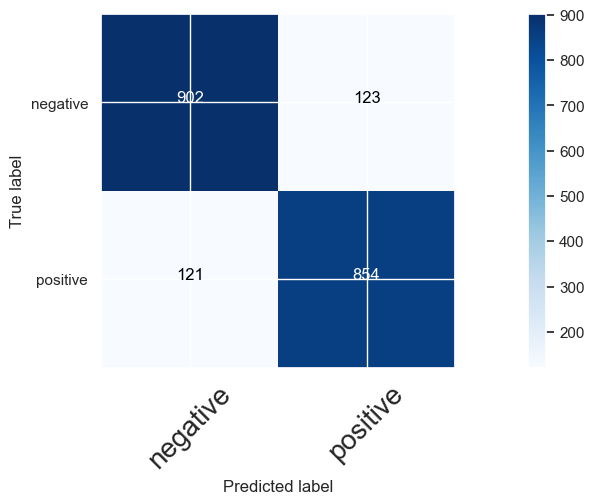

Final Accuracy
0.878


In [128]:
print("Predicting sentiment on the test set")
y_pred = max_ent_bigram_tfidf_chi2_cls.predict(test_text_bigram_tfidf_chi2_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

### Resultados

- Bigramas: 87,65 %
- Bigramas con TF-IDF: 88,60%
- Con bigramas, representación TF-IDF con reducción de características a 5000: 87,4%

## Conclusión

Después de haber hecho pruebas experimentales con distintas combinaciones de pre-procesado, representación y clasificador, el mejor modelo es el siguiente:
- Pre-procesado: eliminación de artefactos HTML, mantener negaciones.
- Representación: Bigramas Bow
- Pesado: TF-IDF
- Clasificador: MaxEnt
- Accuracy: 88,60%


# Redes Neuronales

## 1. Modelos con capas densas

Importamos las dependencias necesarias para construir y entrenar modelos con redes neuronales.

In [33]:
# Importamos capas densas, capas de embeddings y capas para el aplanado de dimensiones
from keras.layers import Dense, Embedding, Flatten, GlobalMaxPool1D

from tensorflow.python.keras.models import Input
# Importamos las herramientas para generar el modelo y trabajar con las entradas
from keras.models import Sequential, Model

# Utilidades para el preprocesado de textos: tokenizador y rellenado de secuencias
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split

# Herramienta para la gestión de las etiquetas de salida
from tensorflow.keras.utils import to_categorical

# Herramienta para implementar Early Stopping (criterios de parada del entrenamiento)
from keras.callbacks import EarlyStopping

# Utilidad para el trabajo con embeddings pre-entrenados
from keras.initializers import Constant


2025-11-04 19:49:27.228808: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [34]:
# Con esta función podremos ver cómo evoluciona el entrenamiento y la validación de los modelos.

import matplotlib.pyplot as plt
plt.style.use('ggplot')

def plot_history(history, metric='acc'):
    acc = history.history[metric]
    val_acc = history.history[f'val_{metric}']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training acc')
    plt.plot(x, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

Estos son algunos de los hiperparámetros con los que vamos a empezar.

In [35]:
#Número de épocas (iteraciones globales)
epochs = 40
#Dimensión de la capa de embeddings
emb_dim = 50
#Tamaño de batch (lote)
batch_size = 32
#Número de palabras tenidas en cuenta (reducción del vocabulario)
n_most_common_words = 50000
#Máxima longitud del documento
max_len = 512


Usamos directamente el pesado TF-IDF.

In [39]:
from sklearn.feature_extraction.text import TfidfTransformer

X_train["all"] = X_train[['clean_review_v2']].apply(lambda x: ''.join(x), axis=1)
X_test["all"] = X_test[['clean_review_v2']].apply(lambda x: ''.join(x), axis=1)

count_vect = CountVectorizer(analyzer = "word")
train_features = count_vect.fit_transform(X_train['all'])
test_features = count_vect.transform(X_test['all'])

# Se utiliza L2 (norma euclídea) para normalizar los vectores resultantes
tfidf = TfidfTransformer(norm="l2")
train_text_tfidf_features = tfidf.fit_transform(train_features)
test_text_tfidf_features = tfidf.transform(test_features)     

Convertimos las etiquetas a one-hot encoding.

In [40]:
Y_train = to_categorical(encoded_y_train, 2)
Y_test = to_categorical(le.transform(y_test.values), 2)

In [41]:
print("Dimensión de los vectores:", train_text_tfidf_features.shape[1])

Dimensión de los vectores: 41190


Primer modelo a entrenar y evaluar.
2 capas densas y 1 densa de salida.

In [ ]:
model = Sequential()
model.add(Dense(128, input_dim=train_text_tfidf_features.shape[1], activation='softmax'))
model.add(Dense(64, activation='softmax'))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     5,272,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,280,834 (20.14 MB)

 Trainable params: 5,280,834 (20.14 MB)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - acc: 0.4919 - loss: 0.6932 - val_acc: 0.4831 - val_loss: 0.6933
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - acc: 0.5122 - loss: 0.6931 - val_acc: 0.4831 - val_loss: 0.6932
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - acc: 0.5097 - loss: 0.6931 - val_acc: 0.5169 - val_loss: 0.6931
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - acc: 0.5034 - loss: 0.6931 - val_acc: 0.4831 - val_loss: 0.6930
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - acc: 0.5342 - loss: 0.6924 - val_acc: 0.4988 - val_loss: 0.6902
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - acc: 0.6494 - loss: 0.6849 - val_acc: 0.8500 - val_loss: 0.6573
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - acc: 0.8983 - loss: 0.6248 - val_acc: 0.8637 - val_loss: 0.5556
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - acc: 0.9285 - loss: 0.4913 - val_acc: 0.8719 - val_loss: 0.4569
Epoch 9/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms

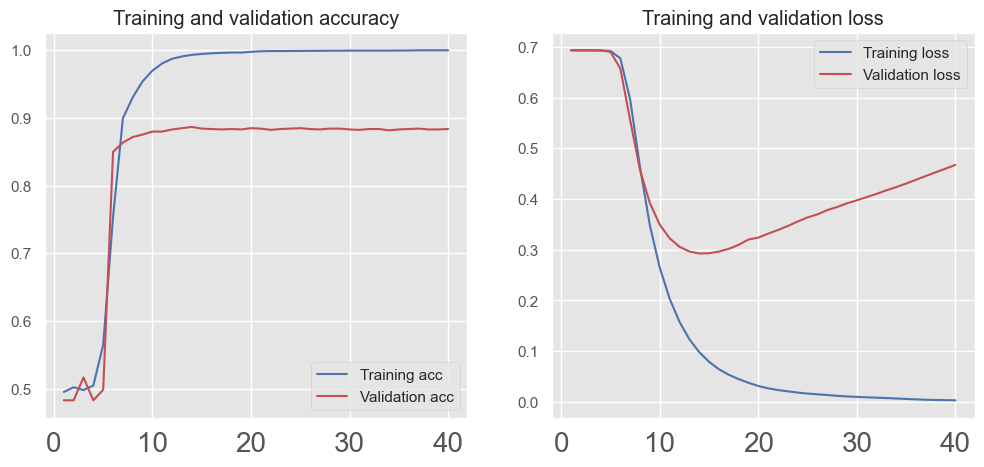

In [136]:
history = model.fit(train_text_tfidf_features.toarray().astype(float), Y_train, epochs=epochs, batch_size=batch_size,validation_split=0.2)
plot_history(history)

A partir de la epoch 15, el las pérdidas de validación empiezan a aumentar, mientras que las de entrenamiento siguen disminuyendo.
Esto indica que el modelo empieza a hacer overfitting.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Classification Report
              precision    recall  f1-score   support

    negative       0.88      0.87      0.88      1025
    positive       0.87      0.88      0.87       975

    accuracy                           0.88      2000
   macro avg       0.87      0.88      0.87      2000
weighted avg       0.88      0.88      0.88      2000

Confusion matrix, without normalization


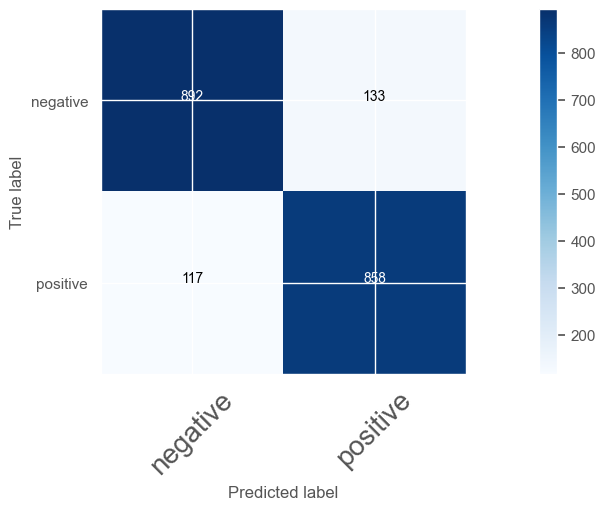

Final Accuracy
0.875


In [137]:
predict_x=model.predict(test_text_tfidf_features.toarray().astype(float)) 
y_pred=np.argmax(predict_x,axis=1)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

Para evitar el overfitting, vamos a usar Early Stopping a la hora de entrenar el siguiente modelo.

In [138]:
model = Sequential()
model.add(Dense(128, input_dim=train_text_tfidf_features.shape[1], activation='softmax'))
model.add(Dense(64, activation='softmax'))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │     5,272,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,280,834 (20.14 MB)

 Trainable params: 5,280,834 (20.14 MB)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - acc: 0.4896 - loss: 0.6933 - val_acc: 0.4831 - val_loss: 0.6933
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - acc: 0.5114 - loss: 0.6931 - val_acc: 0.5169 - val_loss: 0.6931
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - acc: 0.5081 - loss: 0.6931 - val_acc: 0.4831 - val_loss: 0.6935
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - acc: 0.4984 - loss: 0.6931 - val_acc: 0.4831 - val_loss: 0.6929
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - acc: 0.5154 - loss: 0.6922 - val_acc: 0.8231 - val_loss: 0.6896
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - acc: 0.6874 - loss: 0.6844 - val_acc: 0.8450 - val_loss: 0.6574
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - acc: 0.8957 - loss: 0.6247 - val_acc: 0.8619 - val_loss: 0.5557
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - acc: 0.9289 - loss: 0.4895 - val_acc: 0.8788 - val_loss: 0.4565
Epoch 9/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32m

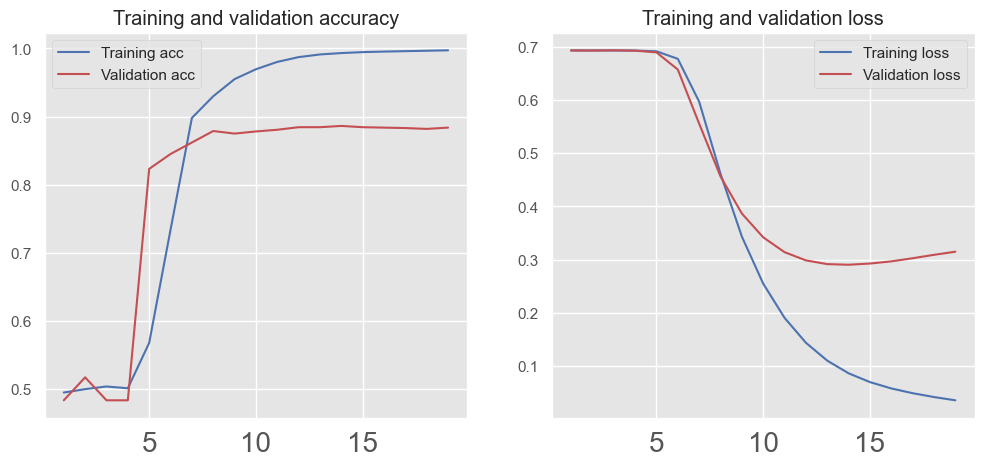

In [139]:
history = model.fit(train_text_tfidf_features.toarray().astype(float), Y_train, epochs=epochs, batch_size=batch_size,validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', mode='min', patience=7, min_delta=0.01)])
plot_history(history)

El entrenamiento ahora se detiene antes de que las pérdidas de validación empiecen a aumentar demasiado.

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Classification Report
              precision    recall  f1-score   support

    negative       0.89      0.88      0.88      1025
    positive       0.87      0.89      0.88       975

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion matrix, without normalization


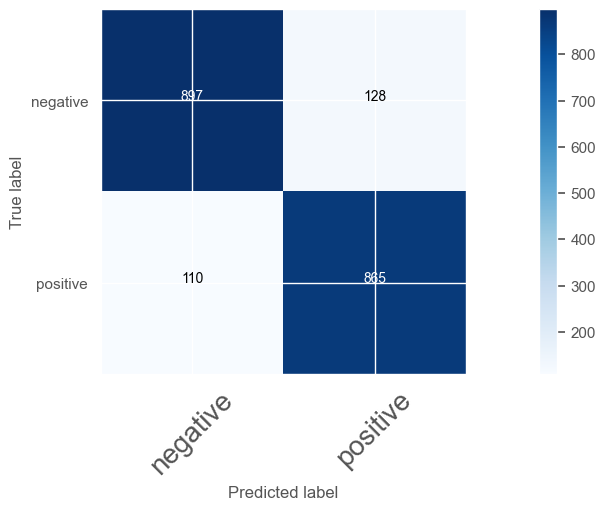

Final Accuracy
0.881


In [140]:
predict_x=model.predict(test_text_tfidf_features.toarray().astype(float)) 
y_pred=np.argmax(predict_x,axis=1)

# Se deshace la transformación de las predicciones para obtener las predicciones como REAL o FAKE
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

Probamos a aumentar ahora el tamaño del batch a 64.
En GPUs es posible que aumentar el tamaño del batch haga el entrenamiento más rápido.

Epoch 1/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - acc: 0.9982 - loss: 0.0306 - val_acc: 0.8844 - val_loss: 0.3179
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - acc: 0.9981 - loss: 0.0307 - val_acc: 0.8844 - val_loss: 0.3216
Epoch 3/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - acc: 0.9991 - loss: 0.0254 - val_acc: 0.8850 - val_loss: 0.3250
Epoch 4/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - acc: 0.9980 - loss: 0.0282 - val_acc: 0.8850 - val_loss: 0.3285
Epoch 5/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - acc: 0.9978 - loss: 0.0285 - val_acc: 0.8856 - val_loss: 0.3316
Epoch 6/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - acc: 0.9992 - loss: 0.0221 - val_acc: 0.8844 - val_loss: 0.3357
Epoch 7/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - acc: 0.9992 - loss: 0.0207 - val_acc: 0.8856 - val_loss: 0.3388
Epoch 8/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - acc: 0.9990 - loss: 0.0204 - val_acc: 0.8850 - val_loss: 0.3418


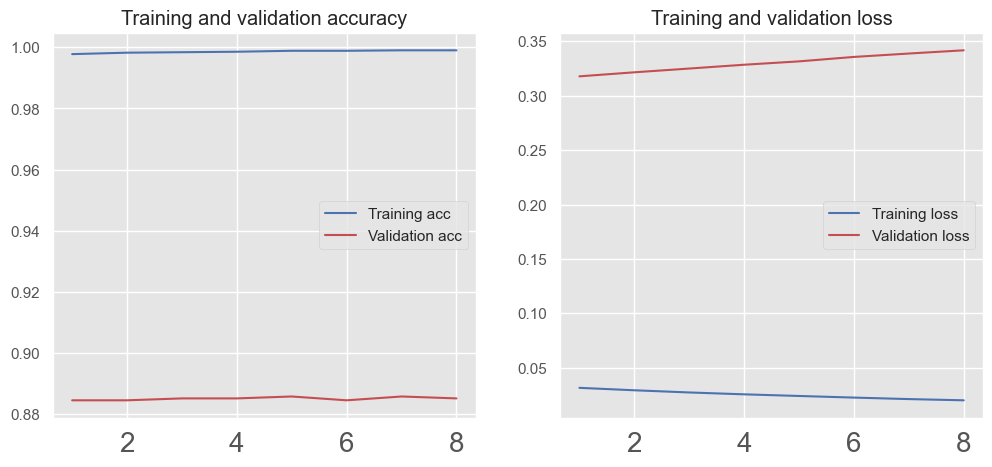

In [141]:
batch_size=64
history = model.fit(train_text_tfidf_features.toarray().astype(float), Y_train, epochs=epochs, batch_size=batch_size,validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', mode='min', patience=7, min_delta=0.01)])
plot_history(history)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Classification Report
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      1025
    positive       0.87      0.89      0.88       975

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion matrix, without normalization


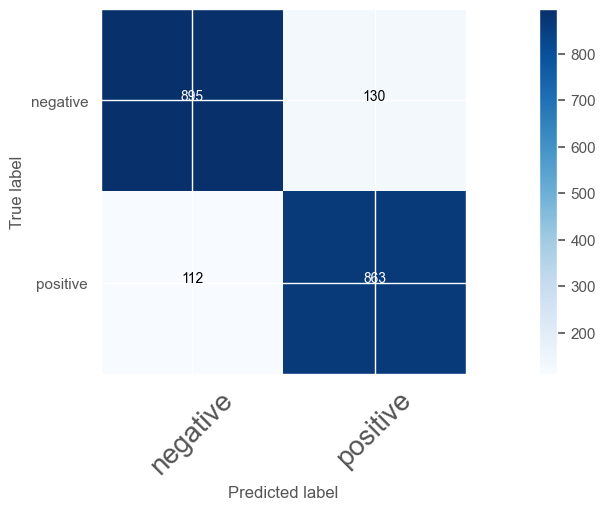

Final Accuracy
0.879


In [142]:
predict_x=model.predict(test_text_tfidf_features.toarray().astype(float)) 
y_pred=np.argmax(predict_x,axis=1)

# Se deshace la transformación de las predicciones para obtener las predicciones como REAL o FAKE
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

Modelo con otra función de activación en las capas ocultas (relu).

In [143]:
model = Sequential()
model.add(Dense(128, input_dim=train_text_tfidf_features.shape[1], activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │     5,272,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,280,834 (20.14 MB)

 Trainable params: 5,280,834 (20.14 MB)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - acc: 1.0000 - loss: 3.9405e-05 - val_acc: 0.8669 - val_loss: 0.5937
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - acc: 1.0000 - loss: 2.7262e-05 - val_acc: 0.8662 - val_loss: 0.6115
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - acc: 1.0000 - loss: 2.0755e-05 - val_acc: 0.8669 - val_loss: 0.6272
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - acc: 1.0000 - loss: 1.3848e-05 - val_acc: 0.8656 - val_loss: 0.6412
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - acc: 1.0000 - loss: 1.1640e-05 - val_acc: 0.8656 - val_loss: 0.6540
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - acc: 1.0000 - loss: 8.2850e-06 - val_acc: 0.8644 - val_loss: 0.6657
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - acc: 1.0000 - loss: 6.3547e-06 - val_acc: 0.8637 - val_loss: 0.6767
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - acc: 1.0000 - loss: 5.1737e-06 - val_acc: 0.8650 - val_loss: 0.6868


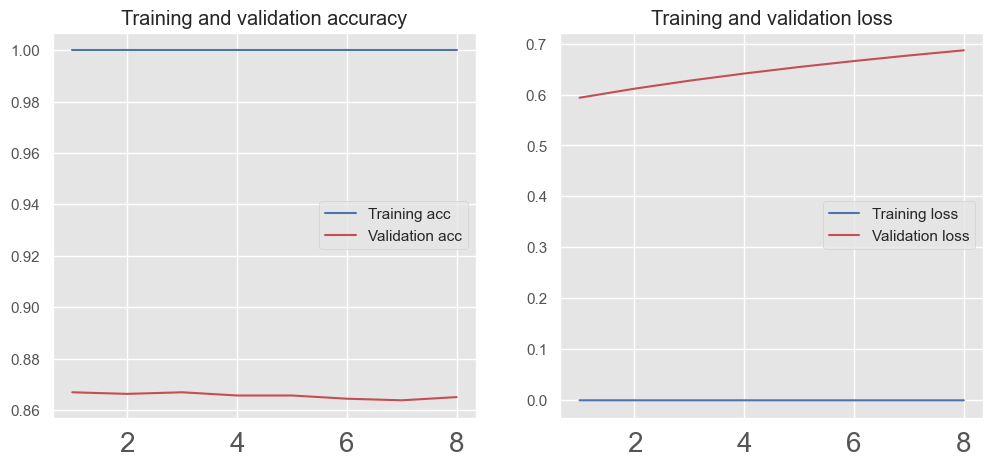

In [146]:
batch_size=32
history = model.fit(train_text_tfidf_features.toarray().astype(float), Y_train, epochs=epochs, batch_size=batch_size,validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', mode='min', patience=7, min_delta=0.01)])
plot_history(history)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Classification Report
              precision    recall  f1-score   support

    negative       0.87      0.86      0.87      1025
    positive       0.85      0.87      0.86       975

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion matrix, without normalization


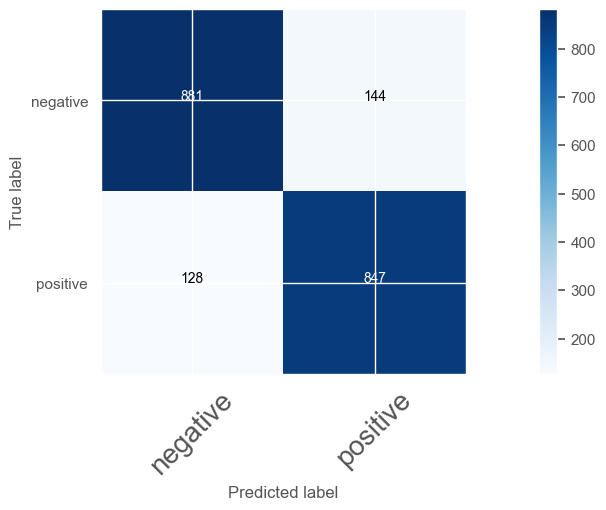

Final Accuracy
0.864


In [147]:
predict_x=model.predict(test_text_tfidf_features.toarray().astype(float)) 
y_pred=np.argmax(predict_x,axis=1)

# Se deshace la transformación de las predicciones para obtener las predicciones como REAL o FAKE
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

Probamos ahora a cambiar la función de coste a categorical_crossentropy.
(Trataría el problema como un problema de clasificación multiclase con dos clases).

In [38]:
# Categirical crossentropy
batch_size=32
model = Sequential()
model.add(Dense(128, input_dim=train_text_tfidf_features.shape[1], activation='softmax'))
model.add(Dense(64, activation='softmax'))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())
history = model.fit(train_text_tfidf_features.toarray().astype(float), Y_train, epochs=epochs, batch_size=batch_size,validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', mode='min', patience=7, min_delta=0.01)])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     5,272,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,280,834 (20.14 MB)

 Trainable params: 5,280,834 (20.14 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.5037 - loss: 0.6933 - val_accuracy: 0.5169 - val_loss: 0.6931
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5045 - loss: 0.6932 - val_accuracy: 0.5169 - val_loss: 0.6930
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4995 - loss: 0.6931 - val_accuracy: 0.6906 - val_loss: 0.6928
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.5261 - loss: 0.6925 - val_accuracy: 0.8394 - val_loss: 0.6901
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.7331 - loss: 0.6858 - val_accuracy: 0.8487 - val_loss: 0.6575
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8886 - loss: 0.6186 - val_accuracy: 0.8606 - val_loss: 0.5219
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9237 - loss: 0.4366 - val_accuracy: 0.8681 - val_loss: 0.3972
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9500 - loss: 0.2826 - va

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Classification Report
              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      1025
    positive       0.87      0.89      0.88       975

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion matrix, without normalization


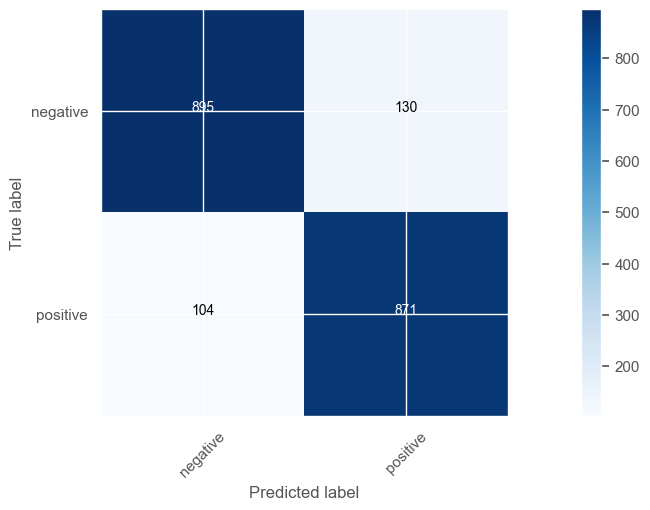

Final Accuracy
0.883


In [39]:
predict_x=model.predict(test_text_tfidf_features.toarray().astype(float)) 
y_pred=np.argmax(predict_x,axis=1)

# Se deshace la transformación de las predicciones para obtener las predicciones como REAL o FAKE
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

Probamos ahora solamente una neurona en la capa de salida con activación sigmoide, cuyo dominio es [0,1].
Al tener una única neurona, entonces una clase se representaría con un 0 y la otra con un 1.
Y habría que usar un threshold de 0.5 por ejemplo para decidir la clase final.

Esto convertiría este problema a clasificación binaria pura, pero esta salida no sería adecuada si en un futuro se
añaden más clases objetivo como 'neutral'.

In [ ]:
# En vez de tener 2 neuronas de salida, tener 1 con activación sigmoide
# Problema puro de clasificación binaria
model = Sequential()
model.add(Dense(128, input_dim=train_text_tfidf_features.shape[1], activation='softmax'))
model.add(Dense(64, activation='softmax'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print(model.summary())

Y_train_binary = np.argmax(Y_train, axis=1) # Convertir etiquetas de one-hot a binarias

history = model.fit(train_text_tfidf_features.toarray().astype(float), Y_train_binary, epochs=epochs, batch_size=batch_size,validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', mode='min', patience=7, min_delta=0.01)])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │     5,272,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,280,769 (20.14 MB)

 Trainable params: 5,280,769 (20.14 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.4884 - loss: 0.6932 - val_accuracy: 0.4831 - val_loss: 0.6935
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.5090 - loss: 0.6931 - val_accuracy: 0.4831 - val_loss: 0.6933
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.4793 - loss: 0.6932 - val_accuracy: 0.4831 - val_loss: 0.6931
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.5323 - loss: 0.6929 - val_accuracy: 0.4831 - val_loss: 0.6921
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.5302 - loss: 0.6902 - val_accuracy: 0.8263 - val_loss: 0.6805
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.8879 - loss: 0.6642 - val_accuracy: 0.8606 - val_loss: 0.6087
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.9184 - loss: 0.5571 - val_accuracy: 0.8725 - val_loss: 0.5001
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.9458 - loss: 0.4230 - 

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Classification Report
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      1025
    positive       0.87      0.89      0.88       975

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion matrix, without normalization


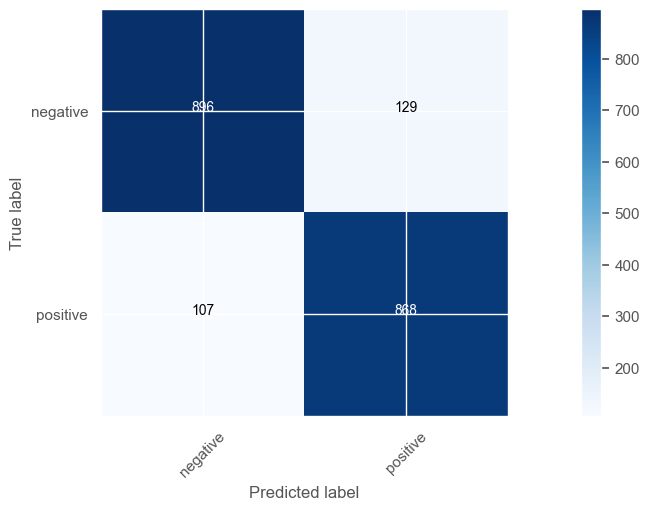

Final Accuracy
0.882


In [44]:
predict_x=model.predict(test_text_tfidf_features.toarray().astype(float))
# 0.5 es el umbral para clasificar entre las dos clases
y_pred = (predict_x > 0.5).astype(int).ravel()

# Se deshace la transformación de las predicciones para obtener las predicciones como REAL o FAKE
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

Vamos a probar ahora con un lr scheduler. La idea es usar un learning rate alto al principio para acelerar el entrenamiento
y después reducirlo para afinar el modelo.
Muestro un plot de cómo evoluciona el learning rate con respecto a las epochs. Es posible que esta técnica sea más adecuada
para entrenar modelos más profundos con más parámetros, pero vamos a probarla igualmente.

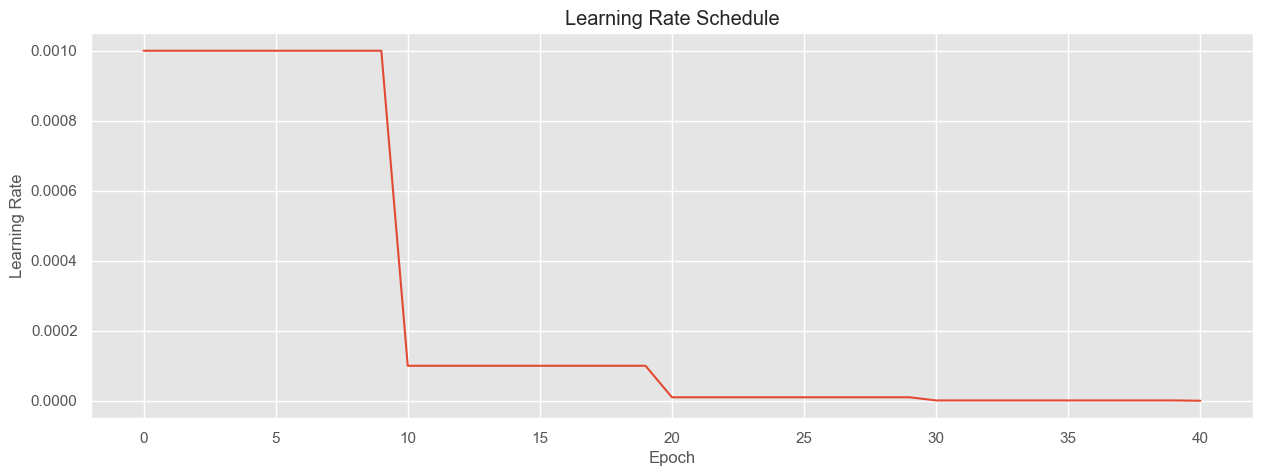

In [93]:
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt

def lr_step_decay(epoch, lr):
    # Cada 10 épocas (0, 10, 20, 30...) dividimos el LR entre 10
    if epoch != 0 and epoch % 10 == 0:
        return lr / 10
    return lr

lr_scheduler = LearningRateScheduler(lr_step_decay, verbose=1)

epochs = 40
initial_lr = 1e-3
lrs = []
for epoch in range(epochs + 1):
    lr = lr_step_decay(epoch, initial_lr)
    lrs.append(lr)
    initial_lr = lr

# Plot
plt.figure()
plt.plot(range(epochs + 1), lrs)
plt.title("Learning Rate Schedule")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()


In [44]:
# Categirical crossentropy
batch_size=32
model = Sequential()
model.add(Dense(128, input_dim=train_text_tfidf_features.shape[1], activation='softmax'))
model.add(Dense(64, activation='softmax'))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())
history = model.fit(train_text_tfidf_features.toarray().astype(float), Y_train, epochs=epochs, batch_size=batch_size,validation_split=0.2,
                    callbacks=[EarlyStopping(monitor='val_loss', mode='min', patience=7, min_delta=0.01), lr_scheduler])


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │     5,272,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,280,834 (20.14 MB)

 Trainable params: 5,280,834 (20.14 MB)

 Non-trainable params: 0 (0.00 B)

None

Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.4901 - loss: 0.6933 - val_accuracy: 0.5169 - val_loss: 0.6930 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.5018 - loss: 0.6932 - val_accuracy: 0.4831 - val_loss: 0.6931 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.5004 - loss: 0.6932 - val_accuracy: 0.4831 - val_loss: 0.6929 - learning_rate: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.5407 - loss: 0.6922 - val_accuracy: 0.4831 - val_loss: 0.6895 - learning_rate: 0.0010

Epoch 5: LearningRateScheduler setting learning rate to 0.00

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Classification Report
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      1025
    positive       0.87      0.89      0.88       975

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion matrix, without normalization


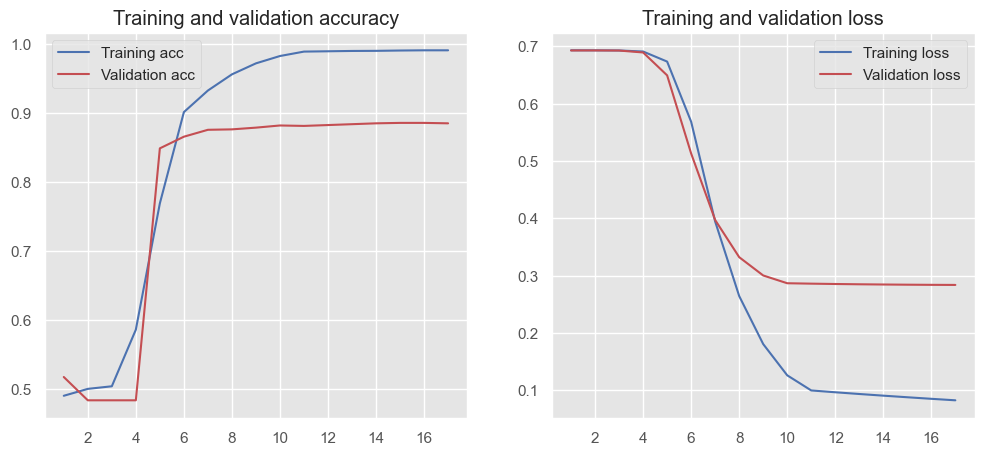

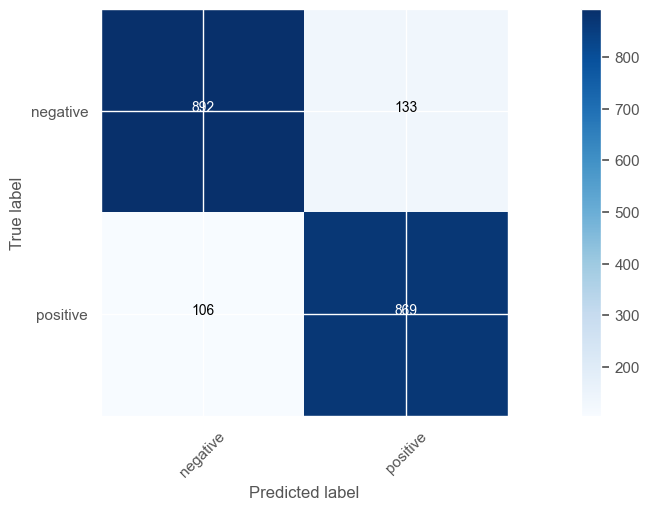

Final Accuracy
0.8805


In [45]:
plot_history(history, metric='accuracy')

predict_x=model.predict(test_text_tfidf_features.toarray().astype(float)) 
y_pred=np.argmax(predict_x,axis=1)

# Se deshace la transformación de las predicciones para obtener las predicciones como REAL o FAKE
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

Aumento la capacidad del modelo con una capa oculta más. Al tener más parámetros el modelo es posible que tenderá a sobreajustar.
Para evitar el sobreajuste, añado un poco de dropout entre capas como regularización.

In [62]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout

batch_size=32
learning_rate = 1e-3

model = Sequential()
model.add(Dense(64, input_dim=train_text_tfidf_features.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer=Adam(learning_rate=learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())
history = model.fit(train_text_tfidf_features.toarray().astype(float), Y_train, epochs=epochs, batch_size=batch_size,validation_split=0.2,
                    callbacks=[EarlyStopping(monitor='val_loss', mode='min', patience=7, min_delta=0.01)])


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 64)             │     2,636,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,642,530 (10.08 MB)

 Trainable params: 2,642,530 (10.08 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.6284 - loss: 0.6418 - val_accuracy: 0.8756 - val_loss: 0.3056
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9303 - loss: 0.2141 - val_accuracy: 0.8737 - val_loss: 0.3288
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9808 - loss: 0.0748 - val_accuracy: 0.8725 - val_loss: 0.4073
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9903 - loss: 0.0369 - val_accuracy: 0.8706 - val_loss: 0.5426
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9947 - loss: 0.0174 - val_accuracy: 0.8725 - val_loss: 0.5786
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9982 - loss: 0.0072 - val_accuracy: 0.8737 - val_loss: 0.6803
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9988 - loss: 0.0050 - val_accuracy: 0.8681 - val_loss: 0.7444
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9994 - loss: 0.0035 - va

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Classification Report
              precision    recall  f1-score   support

    negative       0.87      0.86      0.87      1025
    positive       0.86      0.86      0.86       975

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion matrix, without normalization


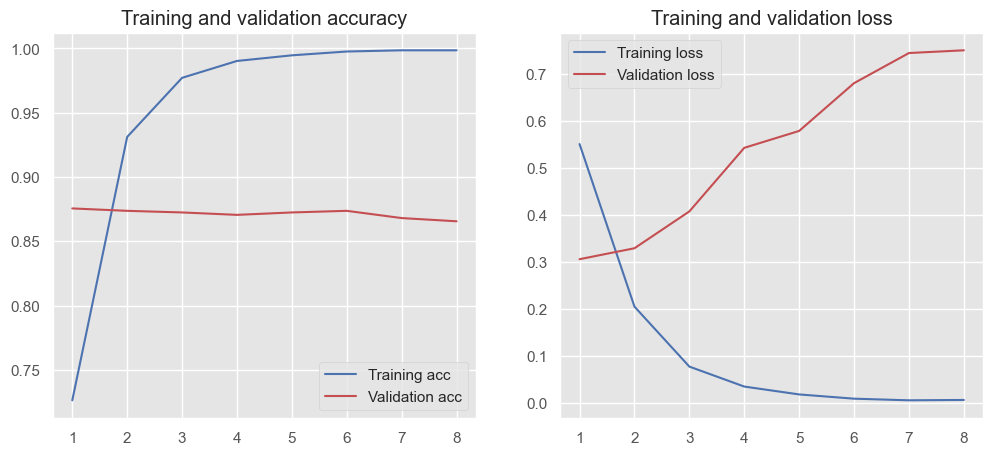

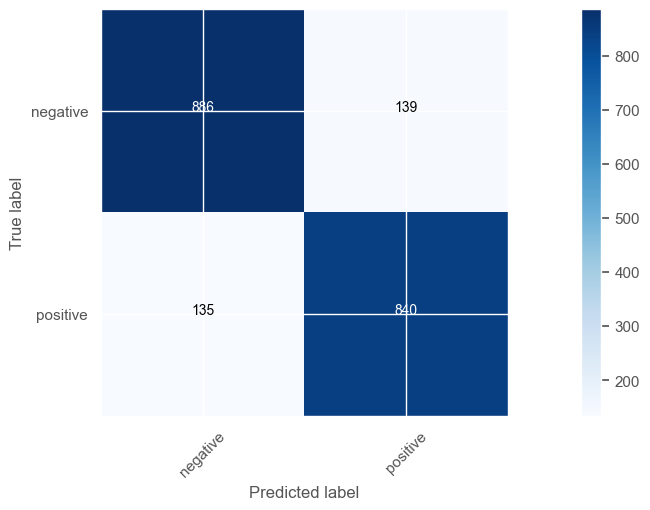

Final Accuracy
0.863


In [63]:
plot_history(history, metric='accuracy')

predict_x=model.predict(test_text_tfidf_features.toarray().astype(float)) 
y_pred=np.argmax(predict_x,axis=1)

# Se deshace la transformación de las predicciones para obtener las predicciones como REAL o FAKE
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

### Conclusión
- Modelo por defecto: 87,50%
- Modelo con Early Stopping: 88,10%
- Modelo con batch size 64 y Early Stopping: 87,90%
- Modelo con activación ReLu y Early Stopping: 86,40%
- Modelo entrenado con loss categorical crossentropy: 88,30%
- Modelo con una neurona de salida y activación sigmoide: 88,20%
- Modelo con learning rate scheduler: 88,05% (El overfitting es menor cuando el lr es más pequeño)
- Modelo con activación ReLu, Dropout y una capa más: 86,30% (El overfitting es mayor, he tratado de añadir Dropout para ver si mejora, pero no ha sido así).
 Es posible que al añadir una capa más, la capacidad del modelo es demasiado alta para este dataset.

Los resultados son relativamente similares. El salto más grande se da al usar Early Stopping.
La acuracy máxima se obtiene con el modelo de una salida y activación sigmoide. Esta accuracy máxima es muy parecida también a la obtenida
con los modelos de aprendizaje clásicos. Pienso que para aprovechar mejor las redes neuronales habría que usar más datos o para este tipo de tarea, usar redes que tengan en cuenta
el orden de las palabras como RNNs o Transformers.


## 2. Modelos con Word Embeddings

In [36]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train.clean_review_v2)
sequences_train = tokenizer.texts_to_sequences(X_train.clean_review_v2)
sequences_test = tokenizer.texts_to_sequences(X_test.clean_review_v2)
vocab_size = len(tokenizer.word_index) + 1

In [37]:
print("Tamaño del vocabulario: ", vocab_size)

Tamaño del vocabulario:  41215


In [38]:
train_text_nn = pad_sequences(sequences_train, maxlen=max_len)
test_text_nn = pad_sequences(sequences_test, maxlen=max_len)

Y_train = to_categorical(encoded_y_train, 2)
Y_test = to_categorical(le.transform(y_test.values), 2)

Añadimos una capa de embedding al modelo seguida de 1 capa densa oculta y 1 capa de salida oculta.
El embedding hará que por cada secuencia de entradad, se genere una matrix de tamaño (max_len, emb_dim) que representará cada palabra de la secuencia
como un vector denso de tamaño emb_dim.
En este modelo, después se aplana esta matrix para pasarla a la capa densa oculta.

In [ ]:
emb_dim = 50

model = Sequential()
model.add(Embedding(input_dim=vocab_size, 
                    output_dim=emb_dim, 
                    input_length=train_text_nn.shape[1]))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print(model.summary())

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc: 0.5871 - loss: 0.6447 - val_acc: 0.8325 - val_loss: 0.4068
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - acc: 0.9489 - loss: 0.1395 - val_acc: 0.8375 - val_loss: 0.3630
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - acc: 0.9966 - loss: 0.0201 - val_acc: 0.8494 - val_loss: 0.4076
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - acc: 1.0000 - loss: 0.0035 - val_acc: 0.8544 - val_loss: 0.4180
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - acc: 1.0000 - loss: 0.0015 - val_acc: 0.8519 - val_loss: 0.4405
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 1.0000 - loss: 9.2848e-04 - val_acc: 0.8525 - val_loss: 0.4496
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - acc: 1.0000 - loss: 5.8376e-04 - val_acc: 0.8525 - val_loss: 0.4640
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - acc: 1.0000 - loss: 4.3675e-04 - val_acc: 0.8537 - val_loss: 0.4740
Epoch 9/40
200/200 ━━━━━━━━━━━━━━━━━

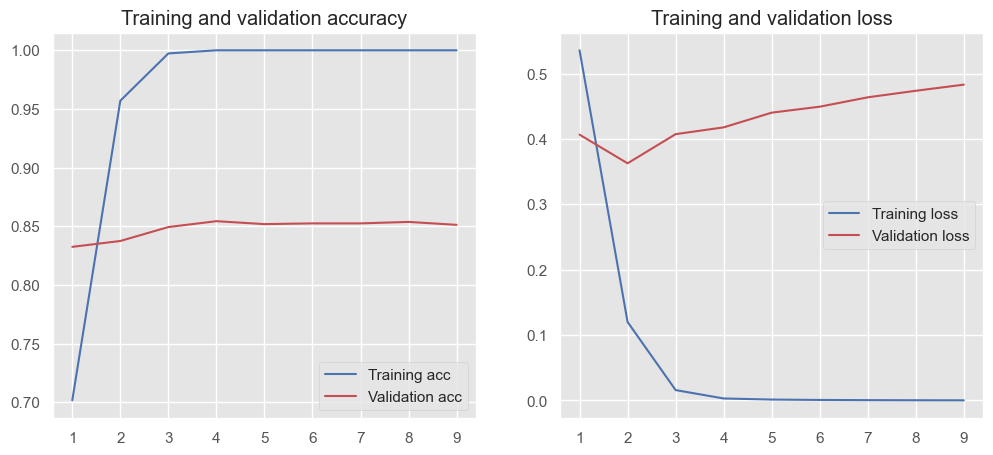

In [70]:
history = model.fit(train_text_nn, Y_train, epochs=epochs, batch_size=batch_size,validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', mode='min', patience=7, min_delta=0.01)])
plot_history(history)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report
              precision    recall  f1-score   support

    negative       0.87      0.84      0.85      1025
    positive       0.84      0.86      0.85       975

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Confusion matrix, without normalization


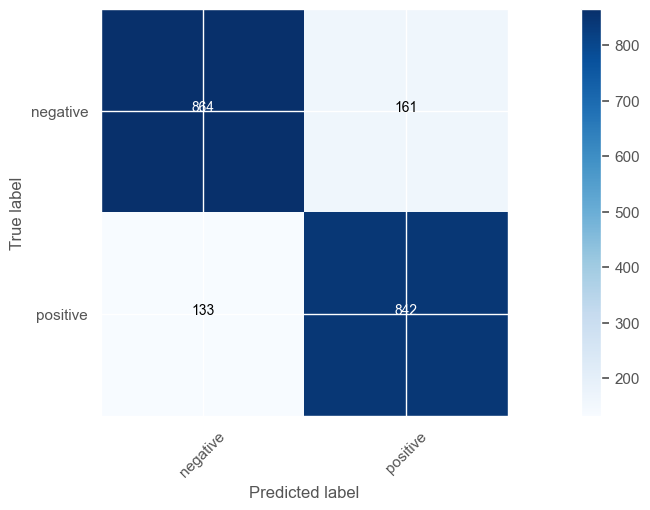

Final Accuracy
0.853


In [71]:
predict_x=model.predict(test_text_nn) 
y_pred=np.argmax(predict_x,axis=1)

# Se deshace la transformación de las predicciones para obtener las predicciones como REAL o FAKE
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

### Embeddings pre-entrenados

In [72]:
import os 

embeddings_index = {}
#Colab
#f = open('/content/drive/My Drive/Colab Notebooks/glove.6B.50d.txt')

#local
f = open('./glove.6B.50d.txt')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()


import os 

embeddings_index = {}
#Colab
#f = open('/content/drive/My Drive/Colab Notebooks/glove.6B.50d.txt')

#local
f = open('./GloVe_embeddings/glove.6B.50d.txt')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()


In [73]:
print('Found %s word vectors.' % len(embeddings_index))
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

Found 400000 word vectors.
Found 41214 unique tokens.


In [74]:
num_words = min(n_most_common_words, len(word_index)) + 1

embedding_matrix = np.zeros((num_words, emb_dim))

for word, i in word_index.items():
    if i > n_most_common_words:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Si la palabra existe añadimos su vector a la matriz
        embedding_matrix[i] = embedding_vector
    else:
        # Si no existe, se le asigna un vector aleatorio
        embedding_matrix[i] = np.random.randn(emb_dim)

In [97]:
emb_dim = 50

model = Sequential()
model.add(Embedding(num_words,
                    emb_dim,
                    embeddings_initializer=Constant(embedding_matrix),
                    input_length=train_text_nn.shape[1],
                    trainable=True))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
print(model.summary())

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - acc: 0.6180 - loss: 0.6813 - val_acc: 0.7431 - val_loss: 0.5129
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - acc: 0.8954 - loss: 0.2758 - val_acc: 0.7556 - val_loss: 0.5543
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - acc: 0.9776 - loss: 0.0823 - val_acc: 0.7581 - val_loss: 0.7185
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - acc: 0.9982 - loss: 0.0198 - val_acc: 0.7606 - val_loss: 0.7561
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - acc: 1.0000 - loss: 0.0046 - val_acc: 0.7675 - val_loss: 0.8166
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - acc: 1.0000 - loss: 0.0021 - val_acc: 0.7619 - val_loss: 0.8570
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - acc: 1.0000 - loss: 0.0012 - val_acc: 0.7625 - val_loss: 0.8883
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - acc: 1.0000 - loss: 8.1272e-04 - val_acc: 0.7613 - val_loss: 0.9147


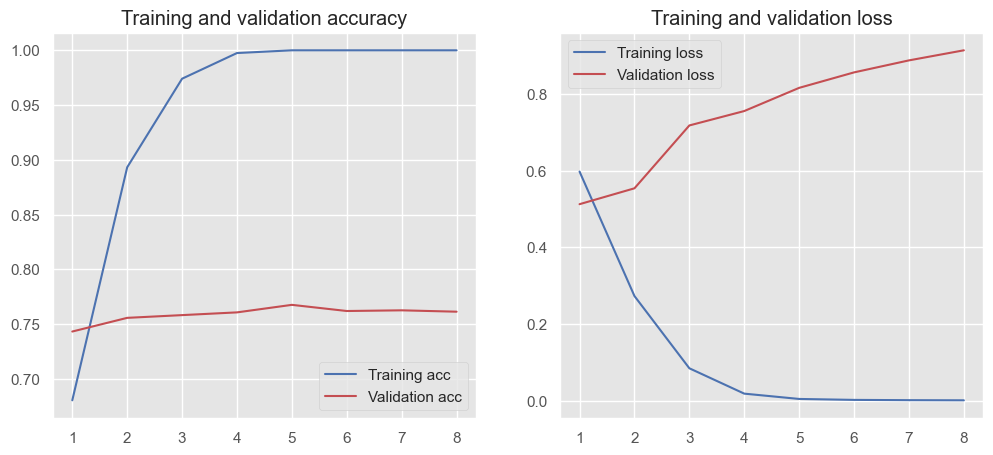

In [81]:
history = model.fit(train_text_nn, Y_train, epochs=epochs, batch_size=batch_size,validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', mode='min', patience=7, min_delta=0.01)])
plot_history(history)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report
              precision    recall  f1-score   support

    negative       0.79      0.77      0.78      1025
    positive       0.77      0.78      0.77       975

    accuracy                           0.78      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.78      0.78      0.78      2000

Confusion matrix, without normalization


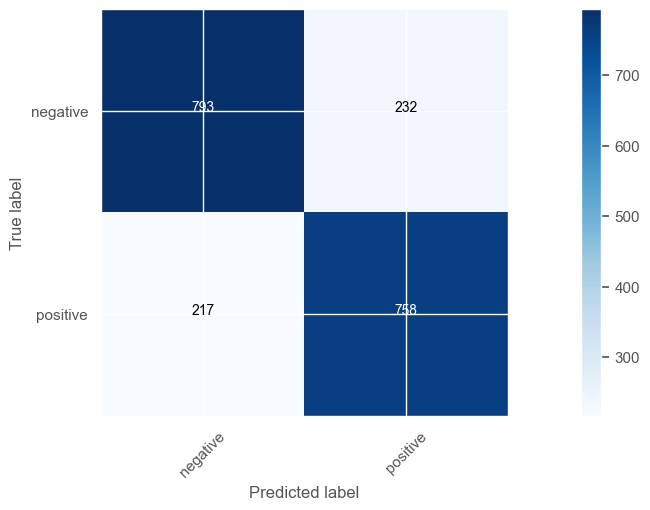

Final Accuracy
0.7755


In [82]:
predict_x=model.predict(test_text_nn) 
y_pred=np.argmax(predict_x,axis=1)

# Se deshace la transformación de las predicciones para obtener las predicciones como REAL o FAKE
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

En vez de aplanar la matriz de embedding uso ahora GlobalAveragePooling1D para ver si
se reduce el overfitting.
Esta capa calcula la media de los vectores de las palabras en la secuencia, condensando toda la dimensión de la secuencia en un único vector de tamaño emb_dim.
Vuelvo a un WE que se entrena desde cero.

In [134]:
from keras.layers import GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam

emb_dim = 64

model = Sequential()
model.add(Embedding(vocab_size, emb_dim, input_length=max_len))
model.add(GlobalAveragePooling1D())
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['acc'])
print(model.summary())

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_30 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_14     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


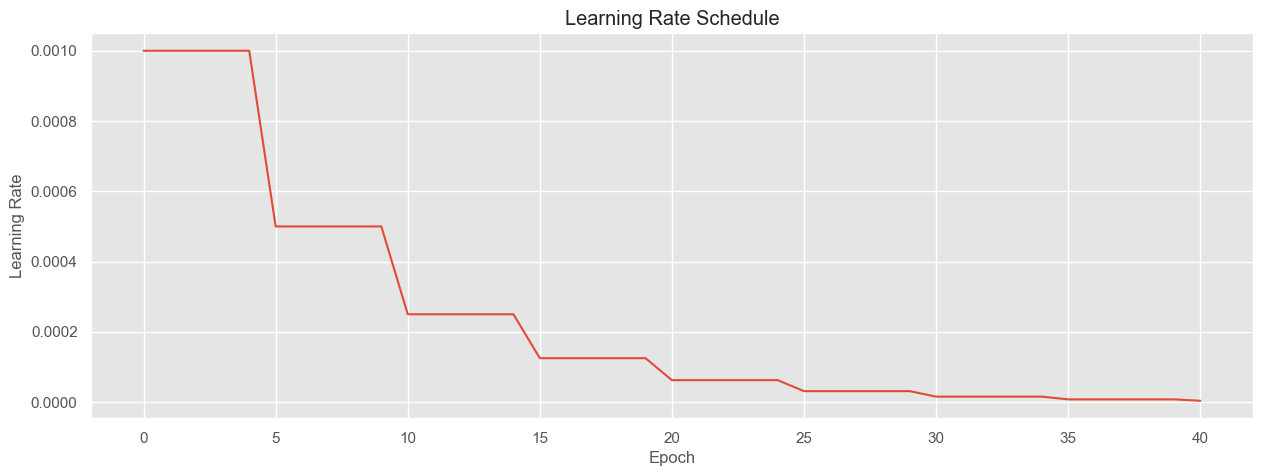

In [133]:
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt

def lr_step_decay(epoch, lr):
    # Cada 5 épocas (0, 5, 10, 15...) dividimos el LR entre 10
    if epoch != 0 and epoch % 5 == 0:
        return lr / 2
    return lr

lr_scheduler = LearningRateScheduler(lr_step_decay, verbose=1)

epochs = 40
initial_lr = 1e-3
lrs = []
for epoch in range(epochs + 1):
    lr = lr_step_decay(epoch, initial_lr)
    lrs.append(lr)
    initial_lr = lr

# Plot
plt.figure()
plt.plot(range(epochs + 1), lrs)
plt.title("Learning Rate Schedule")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()



Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - acc: 0.5107 - loss: 0.6938 - val_acc: 0.5587 - val_loss: 0.6848 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.5920 - loss: 0.6789 - val_acc: 0.6187 - val_loss: 0.5996 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.7132 - loss: 0.5674 - val_acc: 0.8194 - val_loss: 0.4527 - learning_rate: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.8324 - loss: 0.3975 - val_acc: 0.8650 - val_loss: 0.3596 - learning_rate: 0.0010

Epoch 5: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 5/40
200/200 ━━━━━━━━━

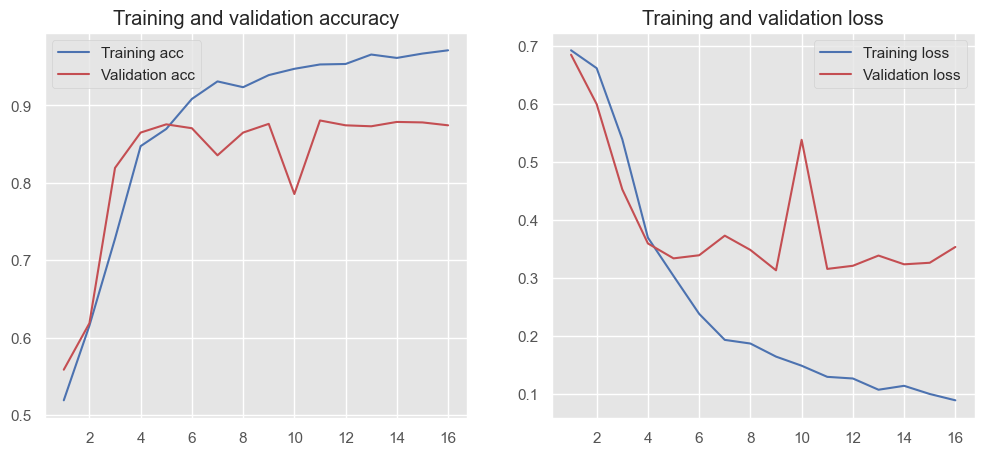

In [135]:
history = model.fit(train_text_nn, Y_train, epochs=epochs, batch_size=batch_size,validation_split=0.2,
                    callbacks=[EarlyStopping(monitor='val_loss', mode='min', patience=7, min_delta=0.01), lr_scheduler])
plot_history(history)

He probado con varios learning rates porque este entrenamiento es algo más inestable.
La inestabilidad se muestra en una gran variación de accuracy entre epochs.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report
              precision    recall  f1-score   support

    negative       0.83      0.92      0.87      1025
    positive       0.90      0.80      0.85       975

    accuracy                           0.86      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.87      0.86      0.86      2000

Confusion matrix, without normalization


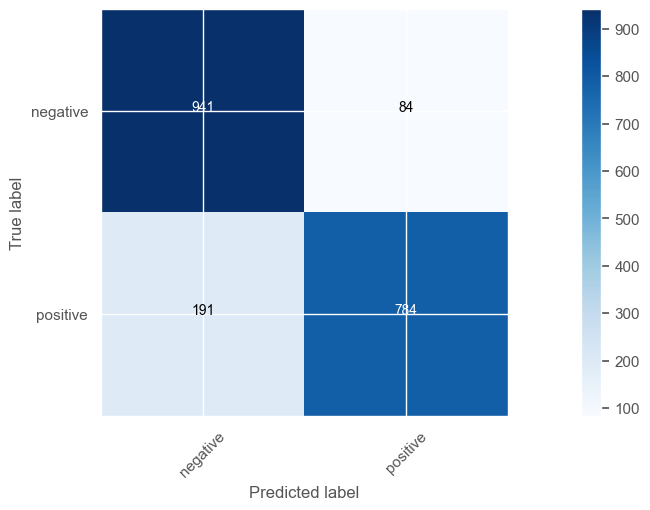

Final Accuracy
0.8625


In [136]:
predict_x=model.predict(test_text_nn) 
y_pred=np.argmax(predict_x,axis=1)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("Final Accuracy")
print(accuracy_score(y_test, y_pred))

### Conclusión
- Modelo con word embeddings: 85,3%
- Modelo con word embeddings pre-entrenados: 77,55%
- Modelo con word embeddings con global avg pooling en vez de flatten: 86,25%

Es posible que los resultados sean peor con los embeddings pre-entrenados porque el vocabulario del dataset o
el preprocesado no encaja bien con cómo se entrenaron esos embeddings.
Como he mencionado anteriormente, para mejorar estos resultados, es posible que sean necesarios más datos de entrenamiento. Datos
más diversos y el uso de arquitecturas que tengan en cuenta el orden de las palabras como RNNs o Transformers.